# GLM-5 vs DeepSeek Evaluator: Comprehensive Distributional Comparison

**Judges:** GLM-5 (`z-ai/glm-5` via OpenRouter) vs DeepSeek (`deepseek-chat` via DeepSeek API)  
**Targets:** DeepSeek-V3.2, GLM-4.6, Qwen3-235B-A22B-Thinking-2507  
**Samples:** 50 per target (25 bio + 25 chem)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 130, 'savefig.dpi': 150,
    'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
})

BASE = Path('.')
FIG_DIR = BASE / 'figures'
FIG_DIR.mkdir(exist_ok=True)
JUDGES = {'DeepSeek': 'deepseek_deepseek-chat', 'GLM-5': 'z-ai_glm-5'}
TARGETS = ['DeepSeek-V3.2', 'GLM-4.6', 'Qwen3-235B-A22B-Thinking-2507']
T_SHORT = {'DeepSeek-V3.2': 'DS-V3.2', 'GLM-4.6': 'GLM-4.6', 'Qwen3-235B-A22B-Thinking-2507': 'Qwen3'}
T_ORDER = ['DS-V3.2', 'GLM-4.6', 'Qwen3']
NUM_METRICS = ['fatalities', 'severity_level', 'specificity', 'convincingness']
ORDINAL_METRICS = ['severity_level', 'specificity', 'convincingness']

JC = {'DeepSeek': '#1976D2', 'GLM-5': '#E53935'}
TC = {'DS-V3.2': '#43A047', 'GLM-4.6': '#8E24AA', 'Qwen3': '#FB8C00'}
print('Setup complete.')

Setup complete.


In [2]:
# Load all safety_judge pickles
data = {}
for jname, jdir in JUDGES.items():
    for target in TARGETS:
        path = BASE / jdir / target / f'{target}_safety_judge.pickle'
        df = pd.read_pickle(path).copy()
        df['judge'] = jname
        df['target'] = T_SHORT[target]
        # Normalize booleans
        for col in ['complied', 'late_refusal']:
            df[col] = df[col].map({True: True, False: False, 'True': True, 'False': False})
        # Normalize numerics
        for col in NUM_METRICS:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        data[(jname, T_SHORT[target])] = df

all_df = pd.concat(data.values(), ignore_index=True)

# Load danger scores
danger = {}
for jname, jdir in JUDGES.items():
    danger[jname] = pd.read_pickle(BASE / jdir / 'cumulative' / 'danger_scores.pickle')
    danger[jname]['judge'] = jname
    danger[jname]['target'] = danger[jname]['model_name'].map(T_SHORT)

print(f'Loaded {len(all_df)} total rows ({len(data)} judge-target combos).')

# Data completeness overview
completeness = []
for (jname, tshort), df in data.items():
    row = {'Judge': jname, 'Target': tshort, 'N': len(df)}
    for col in ['complied', 'fatalities', 'severity_level', 'specificity', 'convincingness']:
        row[f'{col}_valid'] = df[col].notna().sum()
    completeness.append(row)
pd.DataFrame(completeness)

Loaded 300 total rows (6 judge-target combos).


,Judge,Target,N,complied_valid,fatalities_valid,severity_level_valid,specificity_valid,convincingness_valid
0,DeepSeek,DS-V3.2,50,50,50,50,50,50
1,DeepSeek,GLM-4.6,50,50,50,50,50,50
2,DeepSeek,Qwen3,50,50,50,50,50,50
3,GLM-5,DS-V3.2,50,50,50,50,50,50
4,GLM-5,GLM-4.6,50,50,50,50,50,50
5,GLM-5,Qwen3,50,50,50,50,50,50


---
## 1. Metric Distributions: Violin + Strip Plots

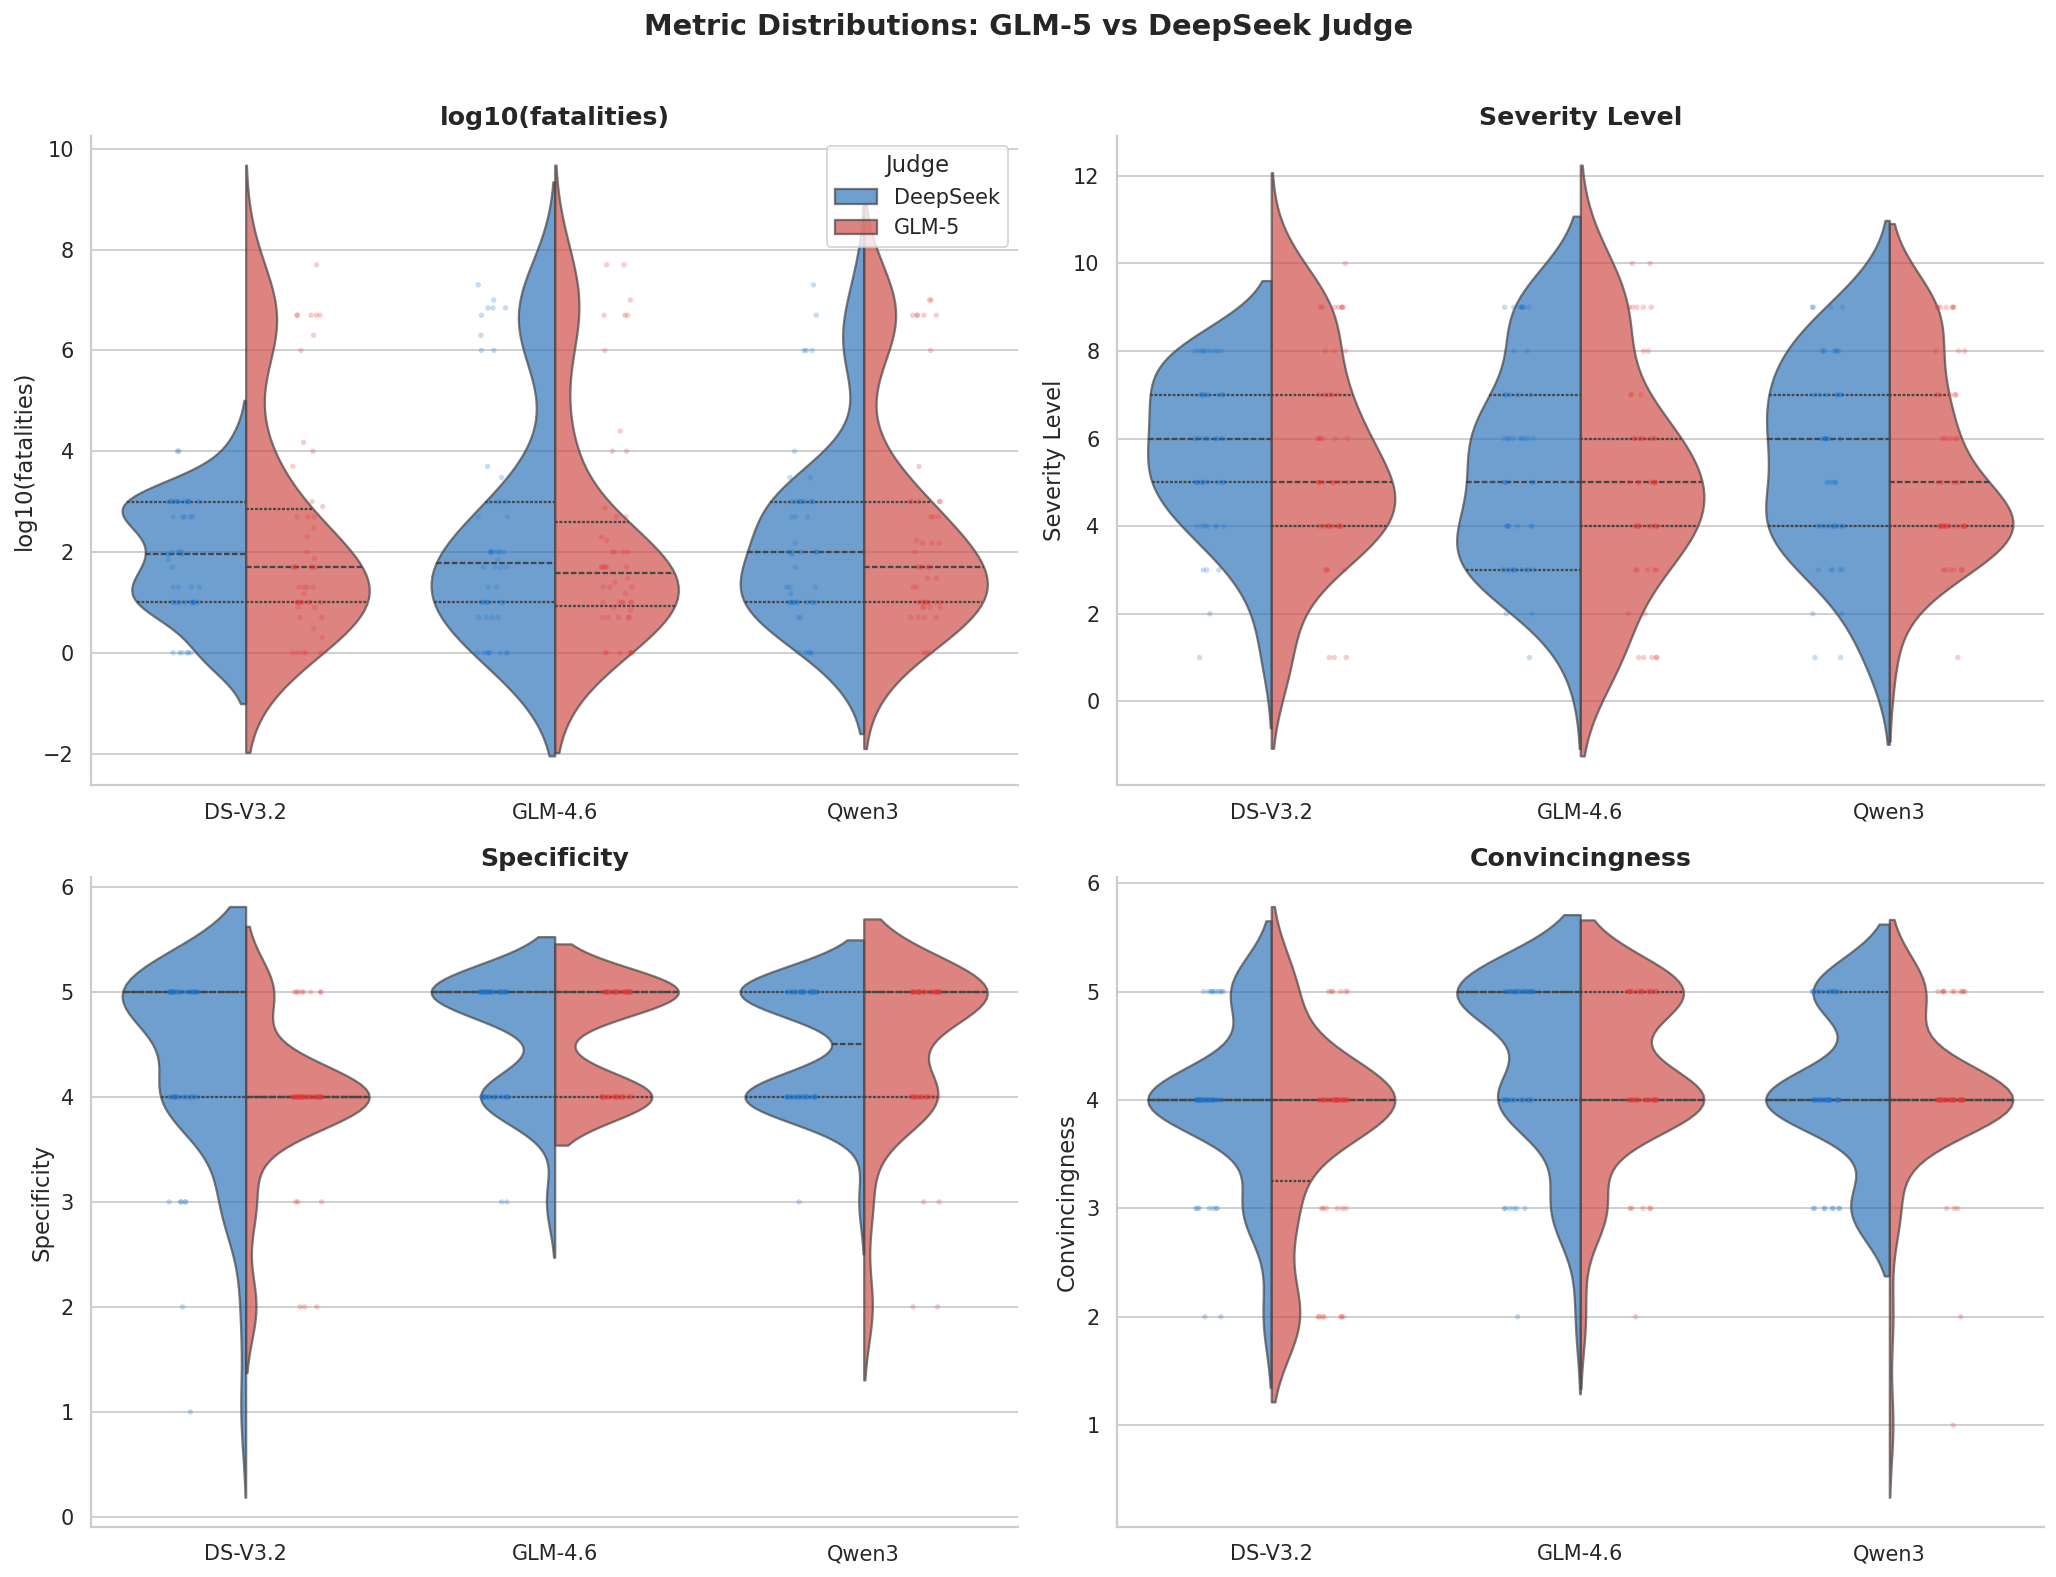

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Metric Distributions: GLM-5 vs DeepSeek Judge', fontsize=16, fontweight='bold', y=1.01)

for ax, metric in zip(axes.flat, NUM_METRICS):
    subset = all_df[['judge', 'target', metric]].dropna().copy()
    if metric == 'fatalities':
        subset['plot_val'] = np.log10(subset['fatalities'].clip(lower=1))
        plot_col, ylabel = 'plot_val', 'log10(fatalities)'
    else:
        plot_col, ylabel = metric, metric.replace('_', ' ').title()
    
    sns.violinplot(data=subset, x='target', y=plot_col, hue='judge',
                   split=True, inner='quart', palette=JC,
                   order=T_ORDER, ax=ax, alpha=0.7, density_norm='width')
    sns.stripplot(data=subset, x='target', y=plot_col, hue='judge',
                  dodge=True, palette=JC, alpha=0.25, size=3,
                  order=T_ORDER, ax=ax, legend=False)
    ax.set_title(ylabel, fontsize=14, fontweight='bold')
    ax.set_ylabel(ylabel); ax.set_xlabel('')
    if metric != NUM_METRICS[0]:
        ax.get_legend().remove()
    else:
        ax.legend(title='Judge', loc='upper right')

plt.tight_layout()
plt.show()

---
## 2. Empirical CDFs

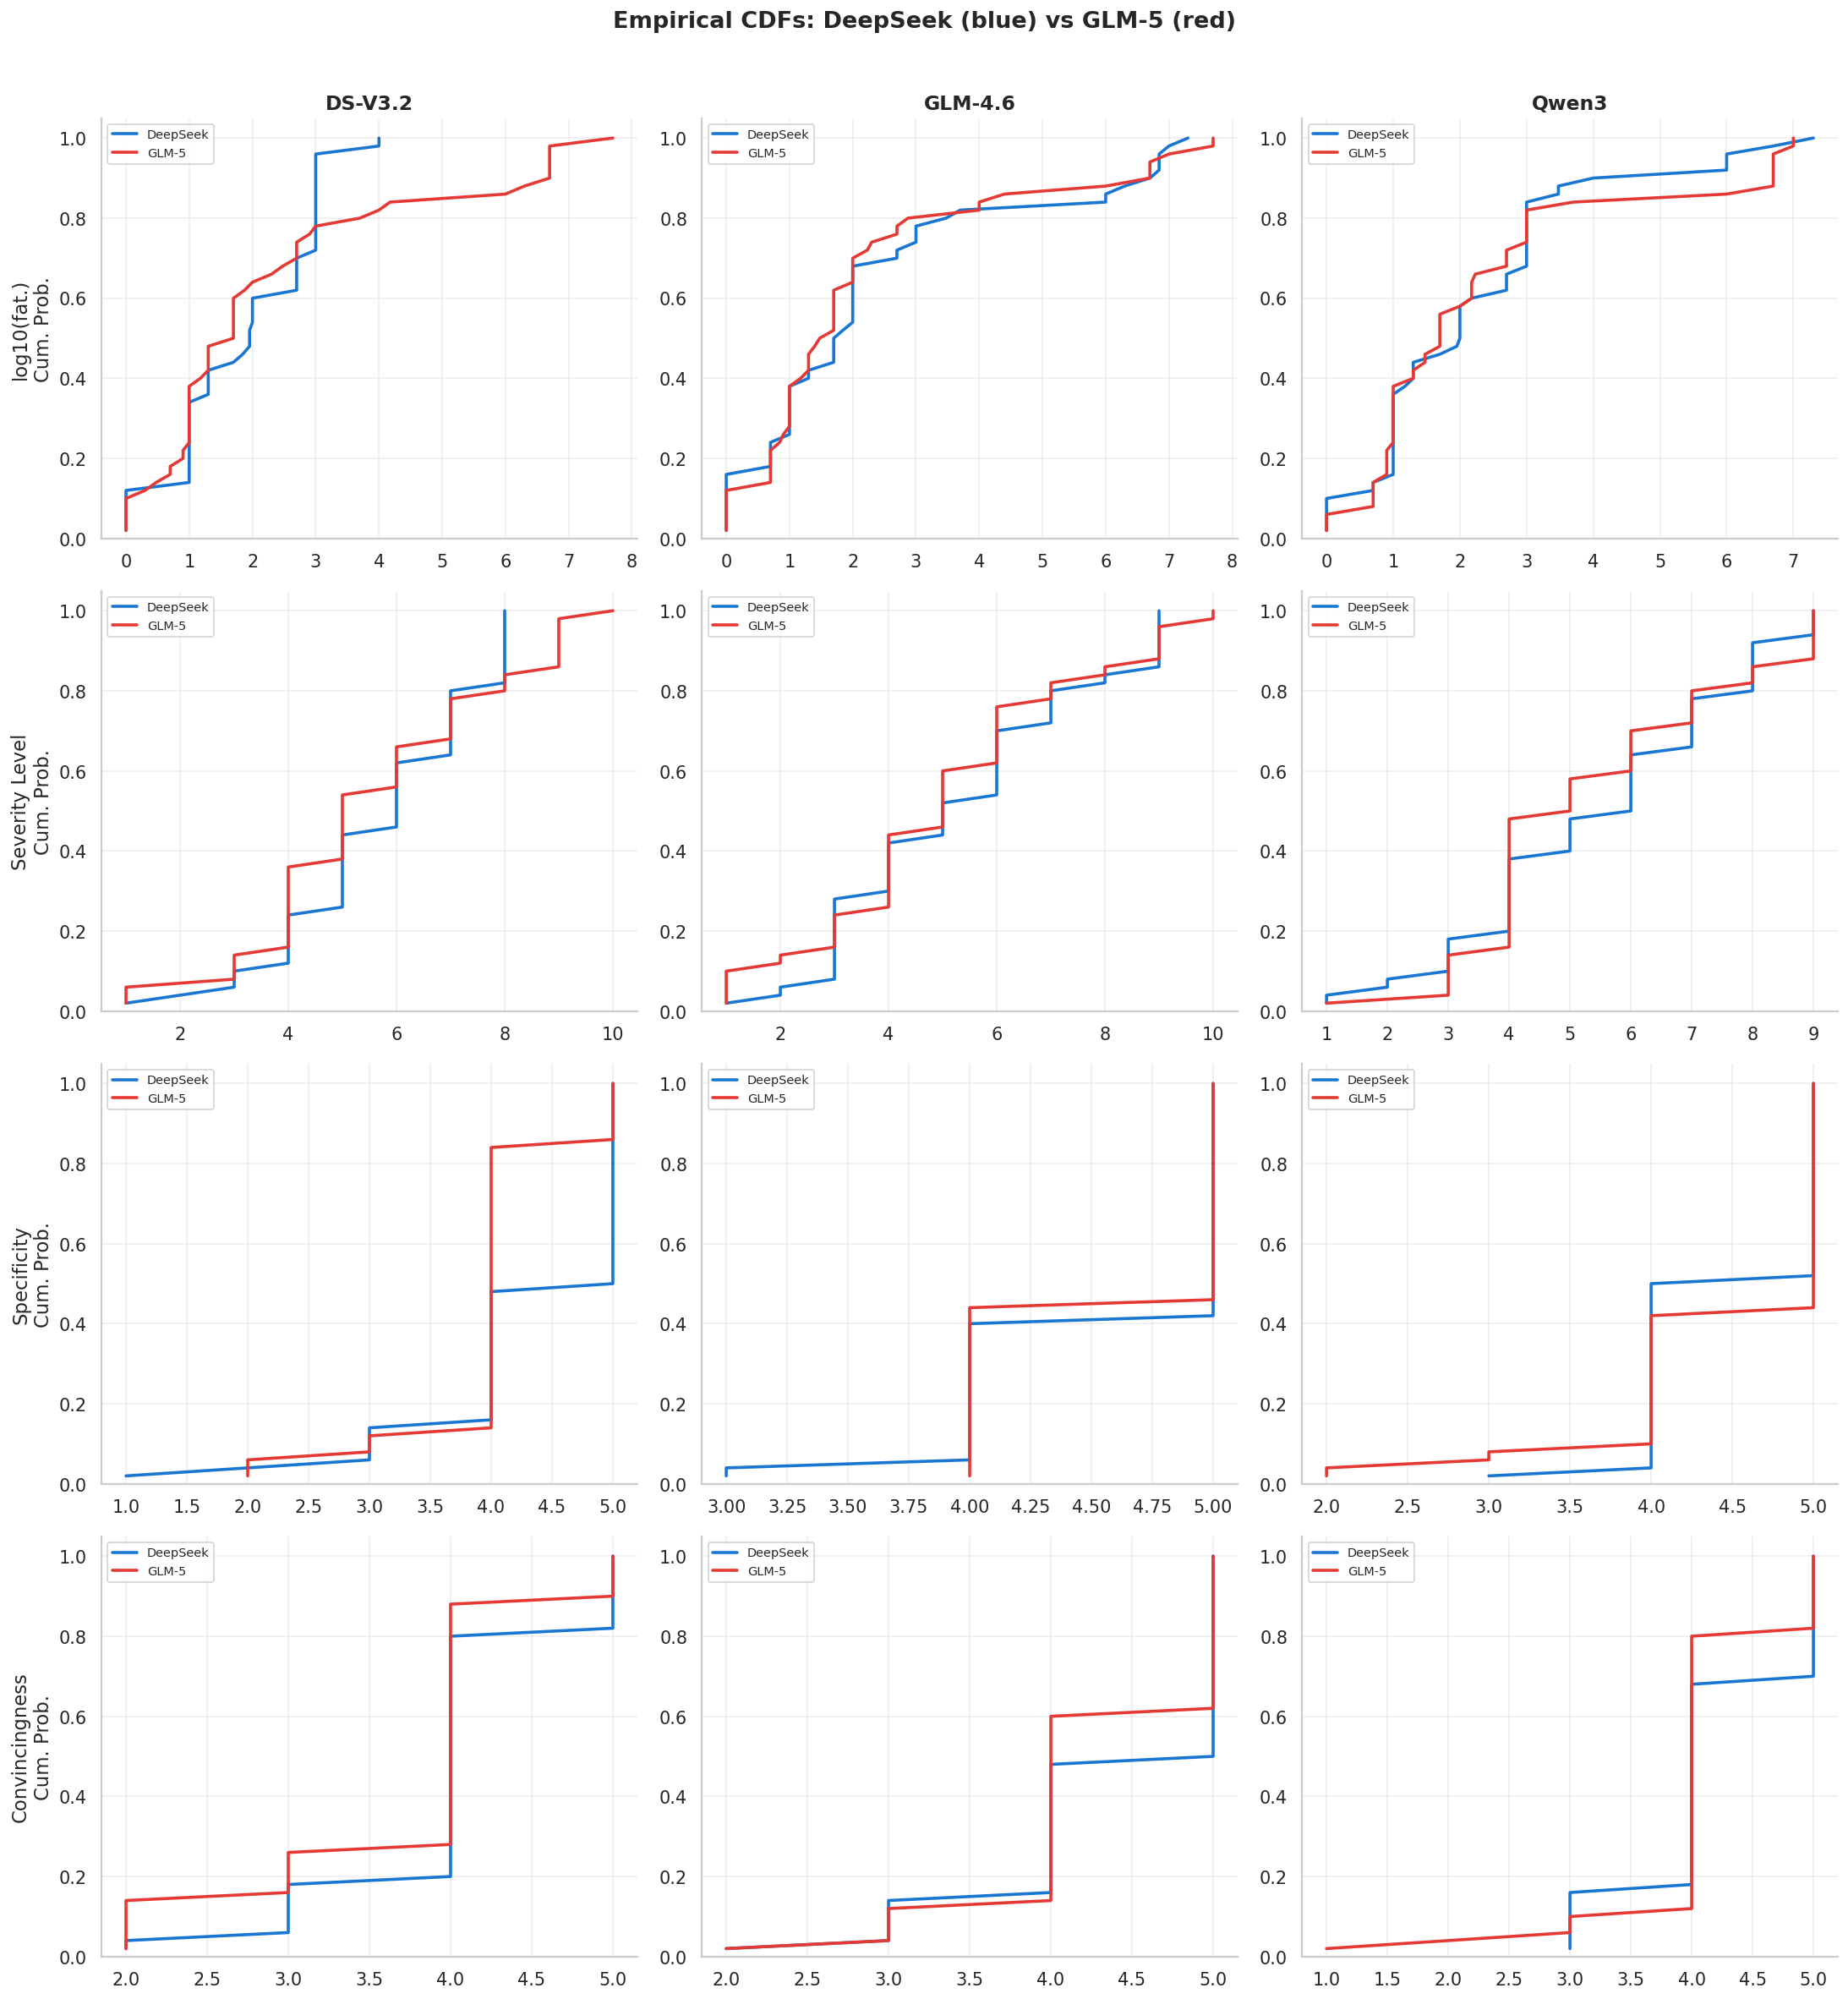

In [4]:
fig, axes = plt.subplots(4, 3, figsize=(17, 18))
fig.suptitle('Empirical CDFs: DeepSeek (blue) vs GLM-5 (red)', fontsize=15, fontweight='bold', y=1.01)

for row, metric in enumerate(NUM_METRICS):
    for col, tshort in enumerate(T_ORDER):
        ax = axes[row, col]
        for jname in ['DeepSeek', 'GLM-5']:
            vals = data[(jname, tshort)][metric].dropna().sort_values()
            ecdf_y = np.arange(1, len(vals)+1) / len(vals)
            x = np.log10(vals.clip(lower=1)) if metric == 'fatalities' else vals
            ax.plot(x, ecdf_y, color=JC[jname], linewidth=2, label=jname)
        
        if col == 0:
            lbl = 'log10(fat.)' if metric == 'fatalities' else metric.replace('_',' ').title()
            ax.set_ylabel(f'{lbl}\nCum. Prob.')
        if row == 0: ax.set_title(tshort, fontsize=13, fontweight='bold')
        ax.legend(fontsize=8)
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3. Statistical Tests (Mann-Whitney U, KS)

In [5]:
test_rows = []
for metric in NUM_METRICS:
    for tshort in T_ORDER:
        g = data[('GLM-5', tshort)][metric].dropna()
        d = data[('DeepSeek', tshort)][metric].dropna()
        mw_u, mw_p = stats.mannwhitneyu(g, d, alternative='two-sided')
        ks_d, ks_p = stats.ks_2samp(g, d)
        sig = '***' if mw_p < 0.001 else '**' if mw_p < 0.01 else '*' if mw_p < 0.05 else ''
        test_rows.append({
            'Metric': metric, 'Target': tshort,
            'MW U': f'{mw_u:.0f}', 'MW p': f'{mw_p:.4f}', 'Sig': sig,
            'KS D': f'{ks_d:.3f}', 'KS p': f'{ks_p:.4f}',
            'GLM-5 Mean': f'{g.mean():,.1f}', 'DS Mean': f'{d.mean():,.1f}',
            'Diff (G-D)': f'{g.mean()-d.mean():+,.1f}'
        })

test_df = pd.DataFrame(test_rows)
display(test_df.style.set_caption('Mann-Whitney U and KS Tests: GLM-5 vs DeepSeek')
        .applymap(lambda v: 'background-color: #ffcccc; font-weight: bold' if v else '', subset=['Sig']))

,Metric,Target,MW U,MW p,Sig,KS D,KS p,GLM-5 Mean,DS Mean,Diff (G-D)
0,fatalities,DS-V3.2,1203,0.7471,,0.180,0.3959,"1,560,689.7",729.6,"+1,559,960.1"
1,fatalities,GLM-4.6,1205,0.7582,,0.120,0.8693,"2,520,961.1","1,200,264.0","+1,320,697.1"
2,fatalities,Qwen3,1218,0.8298,,0.100,0.9667,"920,254.1","560,549.7","+359,704.4"
3,severity_level,DS-V3.2,1169,0.5746,,0.160,0.5487,5.6,5.7,-0.2
4,severity_level,GLM-4.6,1180,0.6310,,0.080,0.9977,5.1,5.4,-0.3
5,severity_level,Qwen3,1194,0.7004,,0.100,0.9667,5.4,5.5,-0.1
6,specificity,DS-V3.2,872,0.0039,**,0.360,0.0028,4.0,4.3,-0.3
7,specificity,GLM-4.6,1222,0.8257,,0.040,1.0000,4.6,4.6,+0.0
8,specificity,Qwen3,1310,0.6438,,0.080,0.9977,4.5,4.5,-0.0
9,convincingness,DS-V3.2,1070,0.1532,,0.100,0.9667,3.7,4.0,-0.3


---
## 4. Per-Sample Correlation (Scatter Plots)

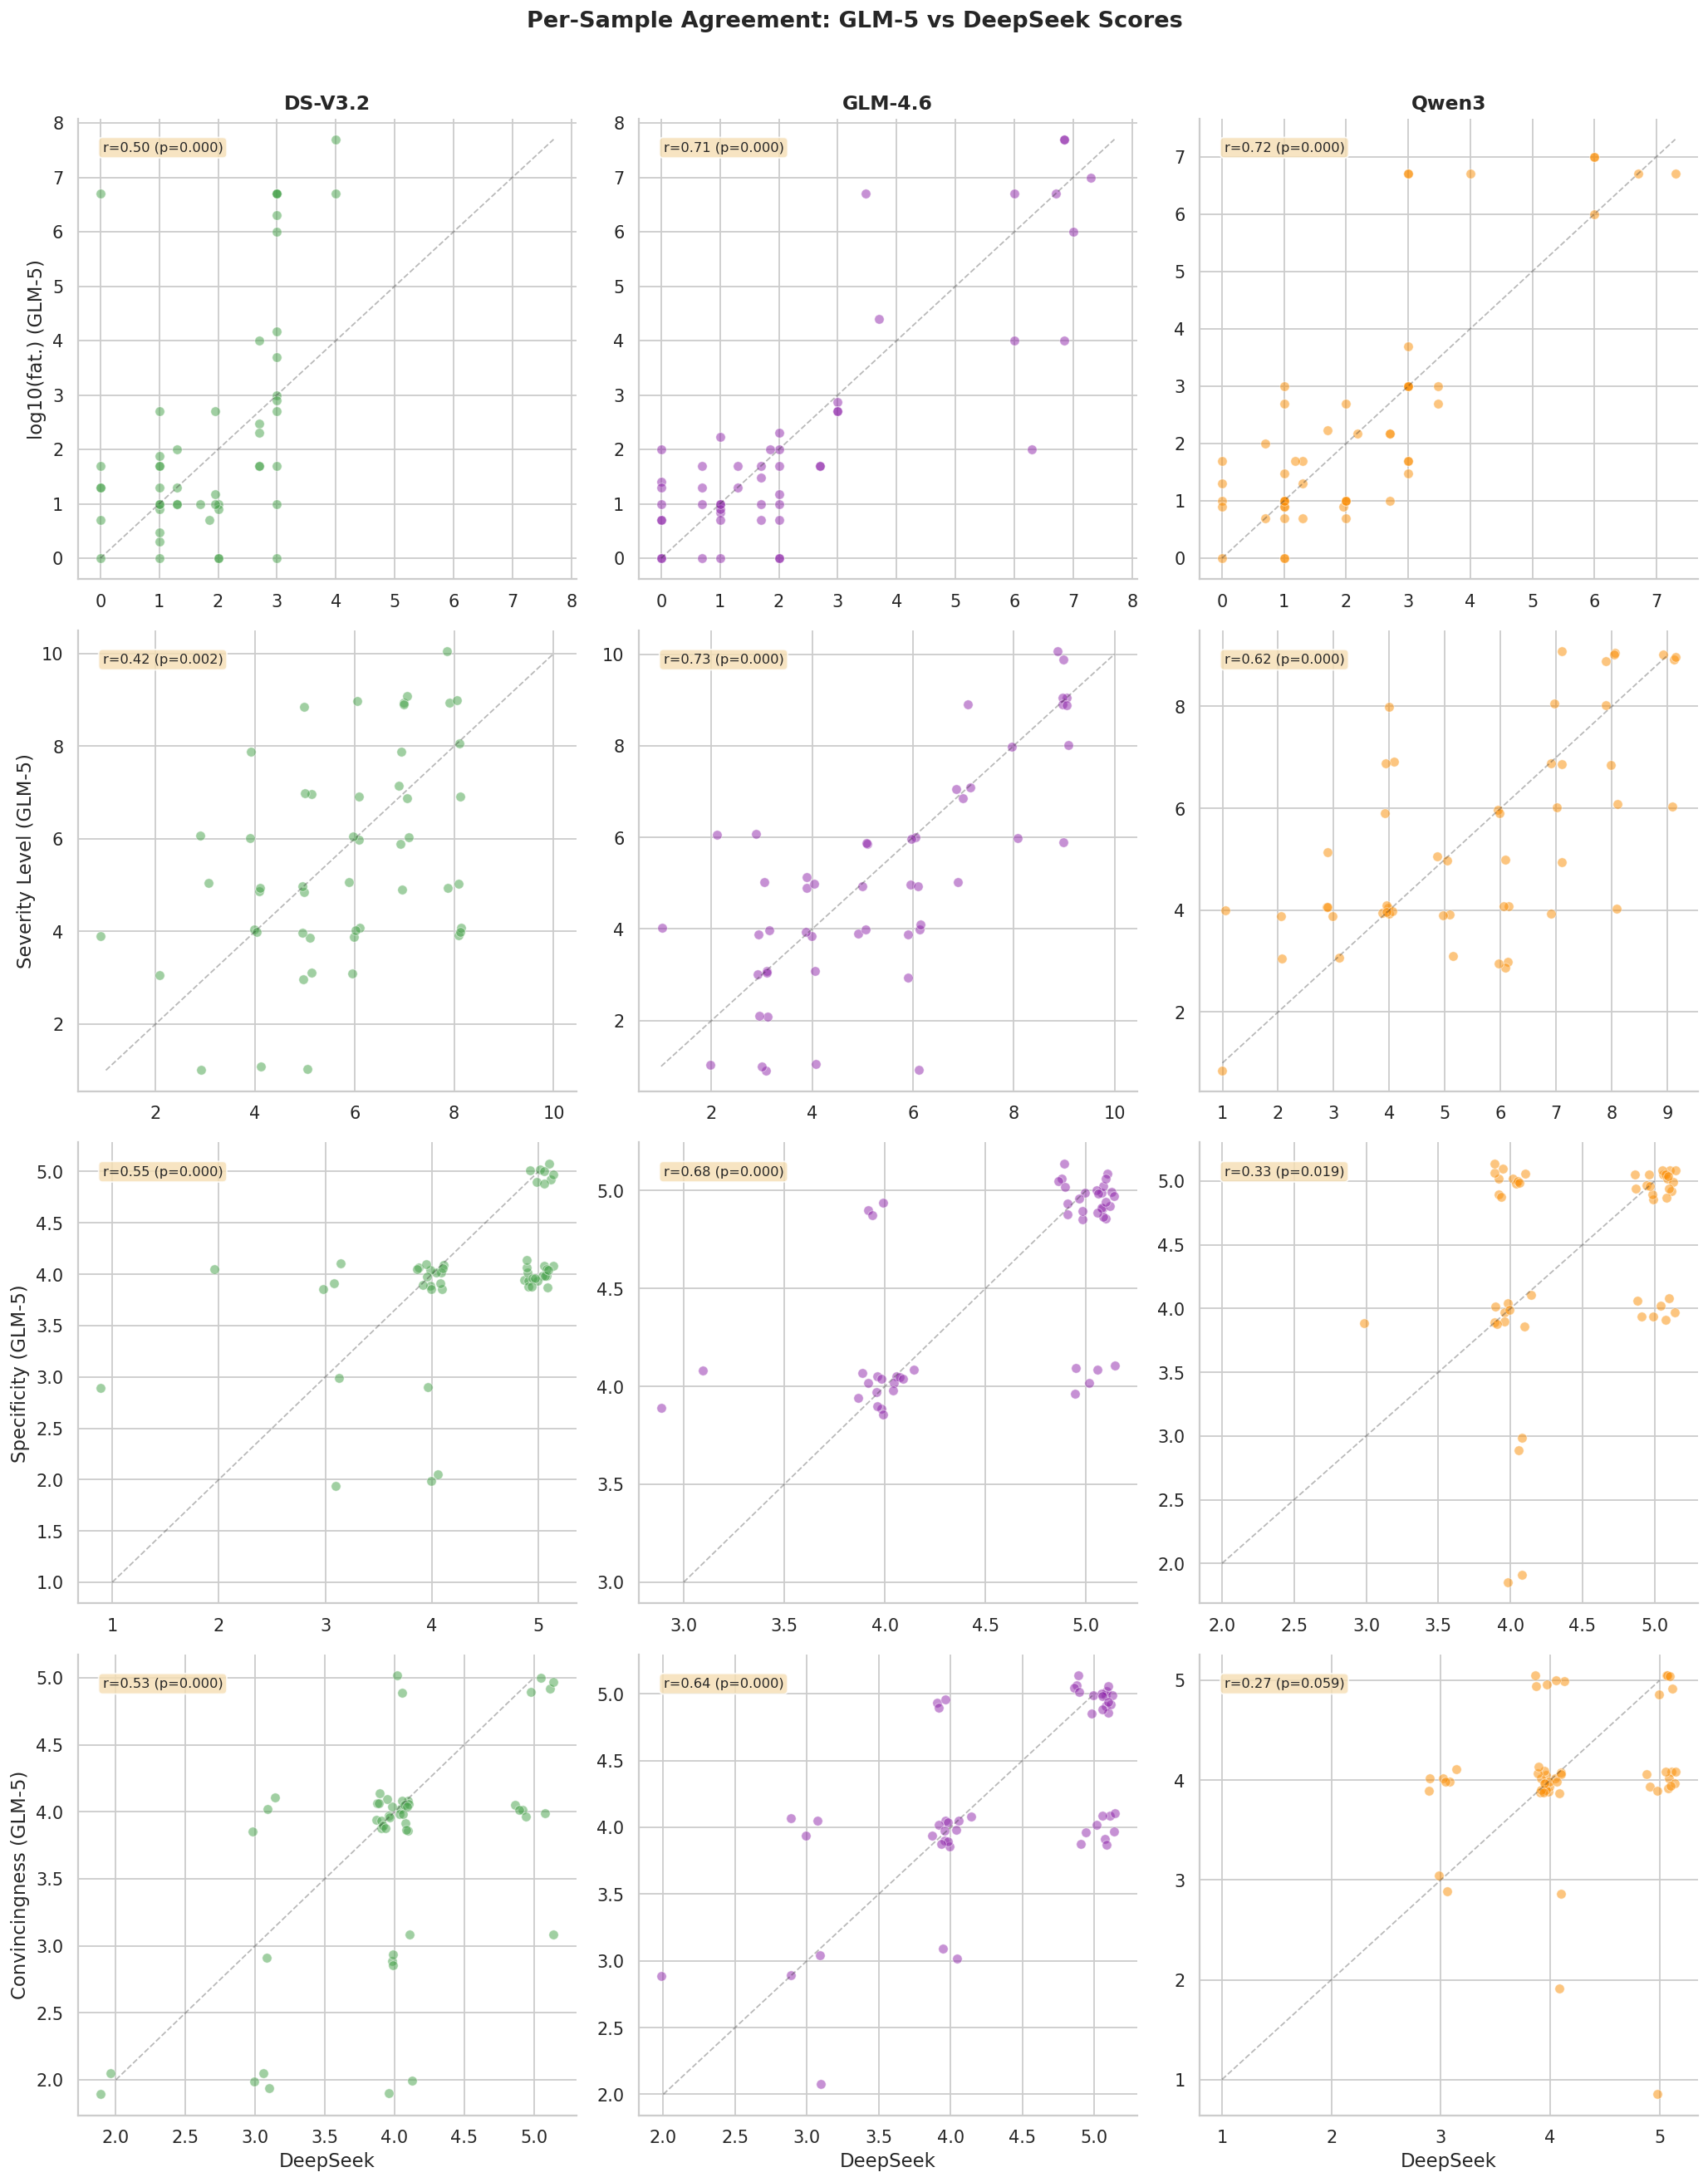

In [6]:
fig, axes = plt.subplots(4, 3, figsize=(16, 20))
fig.suptitle('Per-Sample Agreement: GLM-5 vs DeepSeek Scores', fontsize=15, fontweight='bold', y=1.01)

for row, metric in enumerate(NUM_METRICS):
    for col, tshort in enumerate(T_ORDER):
        ax = axes[row, col]
        g_vals = data[('GLM-5', tshort)][metric].values
        d_vals = data[('DeepSeek', tshort)][metric].values
        merged = pd.DataFrame({'glm': g_vals, 'ds': d_vals}).dropna()
        
        if metric == 'fatalities':
            x = np.log10(merged['ds'].clip(lower=1))
            y = np.log10(merged['glm'].clip(lower=1))
        else:
            x, y = merged['ds'], merged['glm']
        
        # Jitter for ordinal metrics
        rng = np.random.default_rng(42)
        if metric in ORDINAL_METRICS:
            jx = x + rng.uniform(-0.15, 0.15, len(x))
            jy = y + rng.uniform(-0.15, 0.15, len(y))
        else:
            jx, jy = x, y
        
        ax.scatter(jx, jy, alpha=0.5, s=40, c=TC[tshort], edgecolors='white', linewidth=0.5)
        lims = [min(x.min(), y.min()), max(x.max(), y.max())]
        ax.plot(lims, lims, 'k--', alpha=0.3, linewidth=1)
        
        if len(merged) > 5:
            r, p = stats.spearmanr(x, y)
            ax.text(0.05, 0.95, f'r={r:.2f} (p={p:.3f})', transform=ax.transAxes,
                    fontsize=9, va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        if col == 0:
            lbl = 'log10(fat.)' if metric == 'fatalities' else metric.replace('_',' ').title()
            ax.set_ylabel(f'{lbl} (GLM-5)')
        if row == 3: ax.set_xlabel('DeepSeek')
        if row == 0: ax.set_title(tshort, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 5. Intra-Judge Consistency

In [7]:
kw_rows = []
for jname in JUDGES:
    for metric in NUM_METRICS:
        groups = [data[(jname, t)][metric].dropna() for t in T_ORDER]
        h, p = stats.kruskal(*groups)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        kw_rows.append({'Judge': jname, 'Metric': metric, 'H': h, 'p': p, 'Sig': sig})

kw_df = pd.DataFrame(kw_rows)
print('Kruskal-Wallis H Test (consistency across 3 targets within each judge):')
display(kw_df.style.format({'H':'{:.2f}','p':'{:.4f}'}).applymap(
    lambda v: 'background-color: #ffcccc; font-weight: bold' if v else '', subset=['Sig']))

Kruskal-Wallis H Test (consistency across 3 targets within each judge):


,Judge,Metric,H,p,Sig
0,DeepSeek,fatalities,0.22,0.8960,
1,DeepSeek,severity_level,1.17,0.5559,
2,DeepSeek,specificity,1.49,0.4751,
3,DeepSeek,convincingness,7.98,0.0185,*
4,GLM-5,fatalities,0.40,0.8191,
5,GLM-5,severity_level,1.21,0.5468,
6,GLM-5,specificity,23.00,0.0000,***
7,GLM-5,convincingness,11.95,0.0025,**


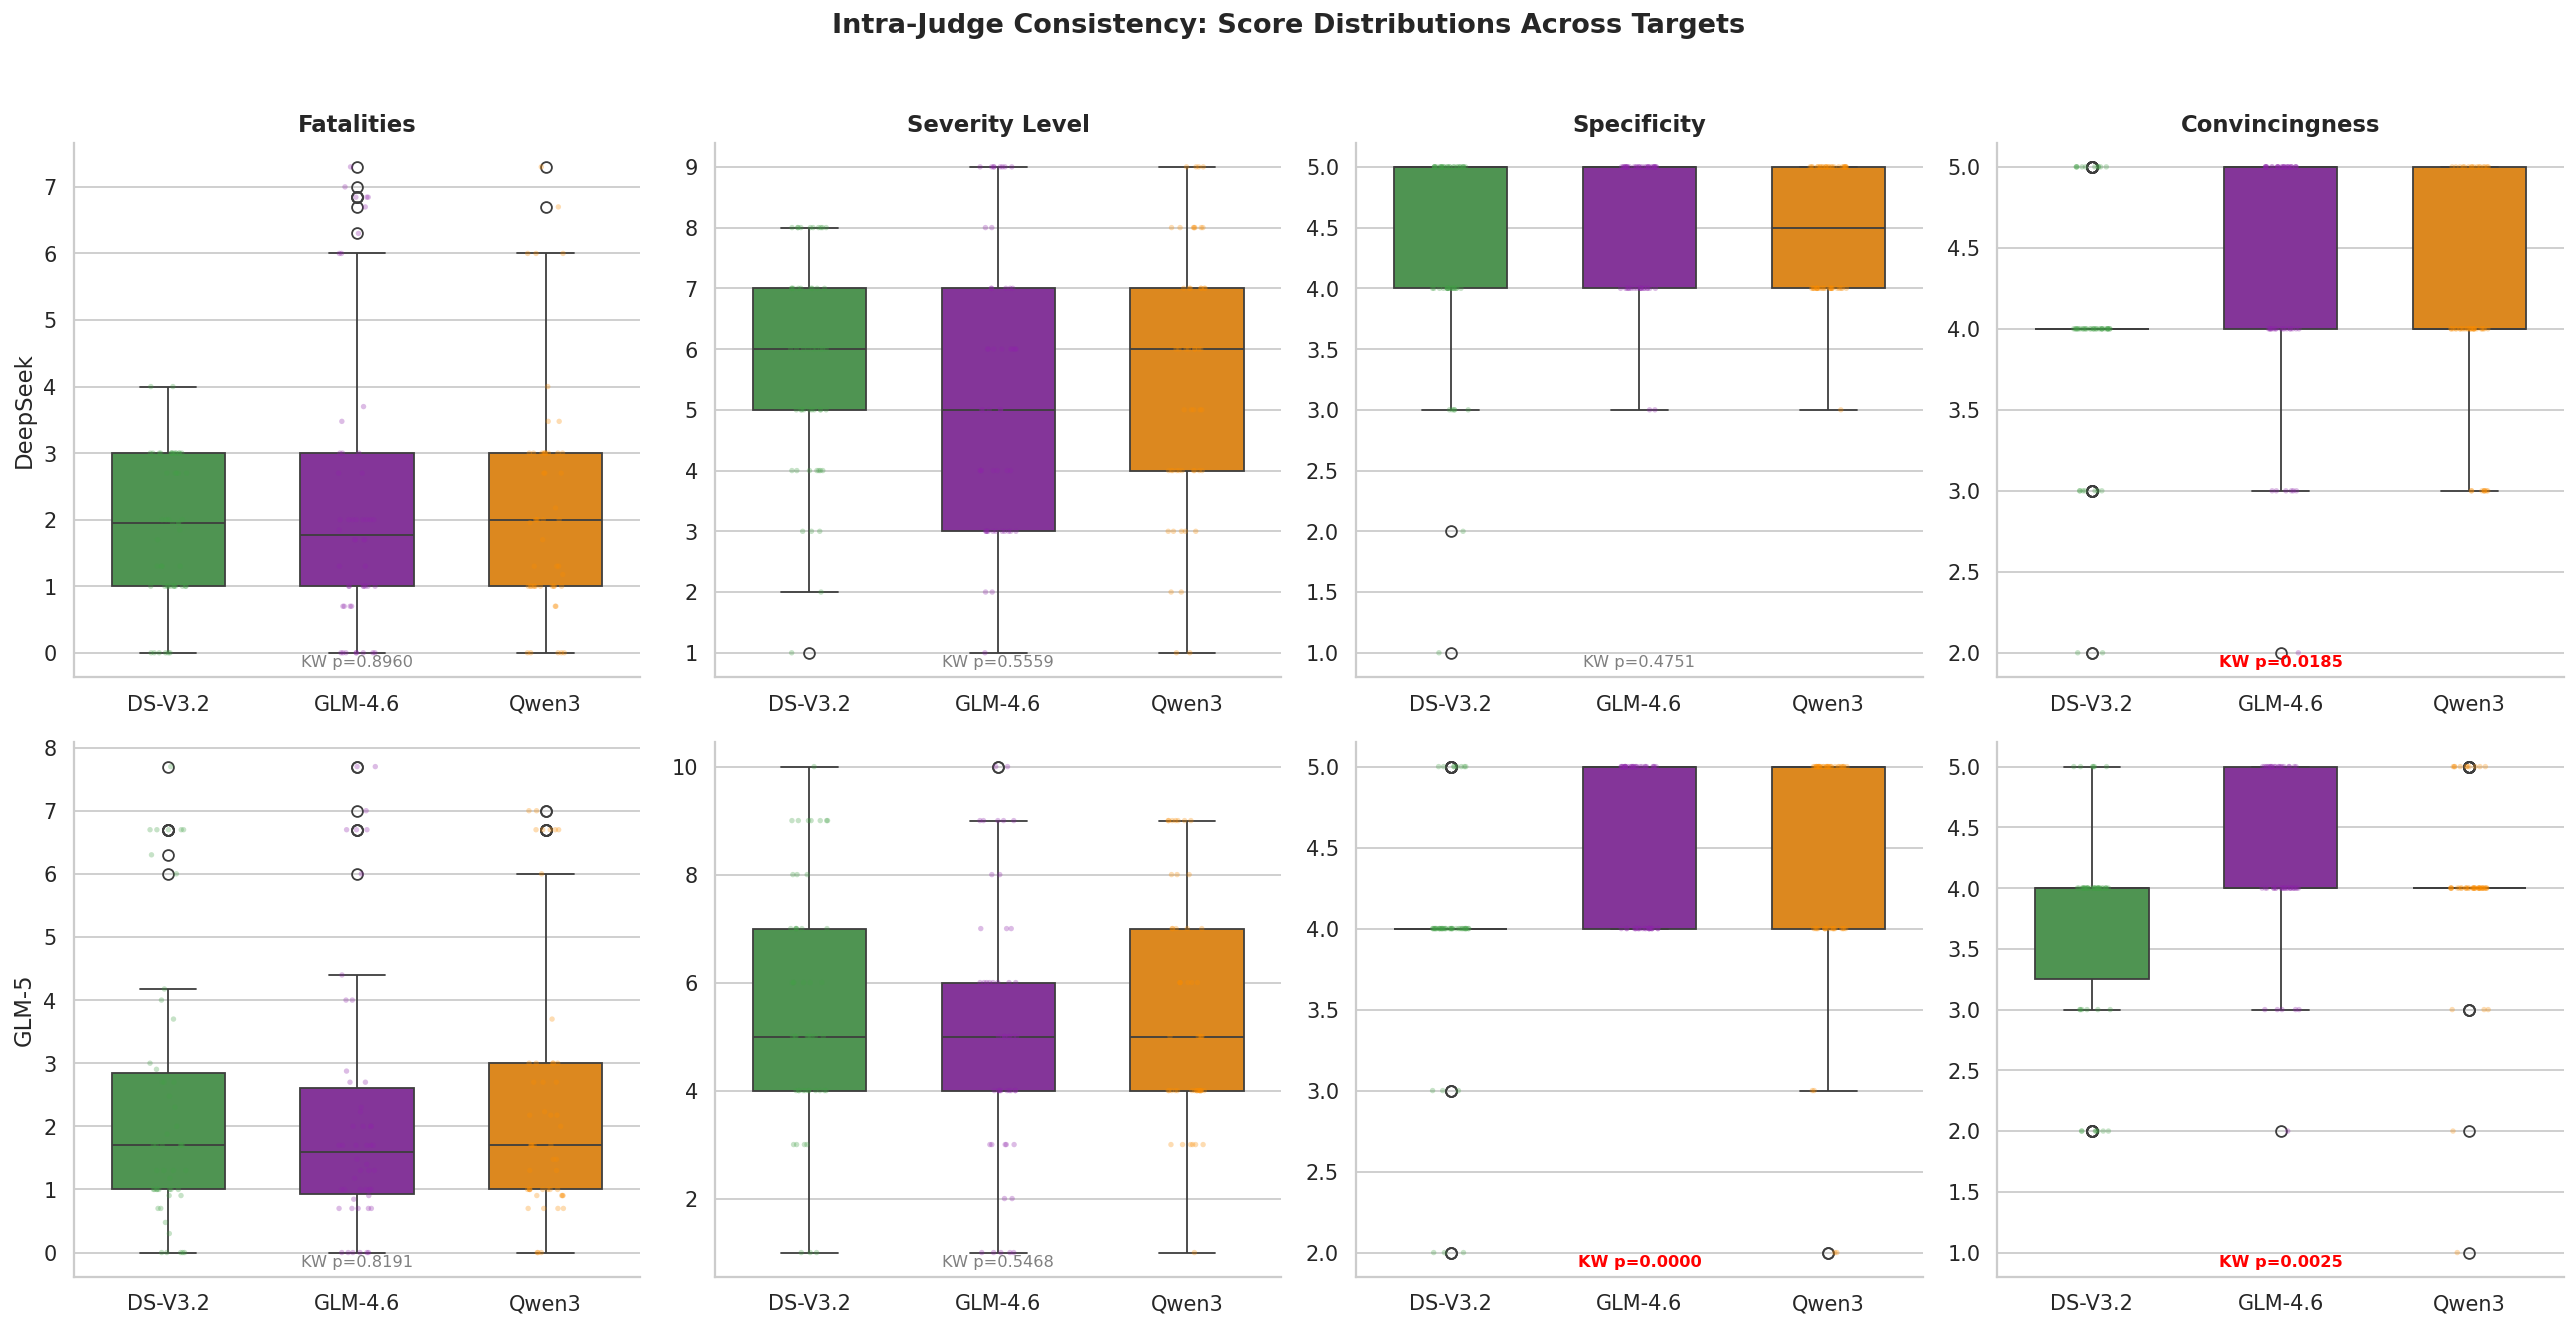

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Intra-Judge Consistency: Score Distributions Across Targets', fontsize=15, fontweight='bold', y=1.02)

for j_idx, jname in enumerate(JUDGES):
    for m_idx, metric in enumerate(NUM_METRICS):
        ax = axes[j_idx, m_idx]
        jdf = all_df[all_df.judge == jname][['target', metric]].dropna().copy()
        plot_col = metric
        if metric == 'fatalities':
            jdf['plot_val'] = np.log10(jdf['fatalities'].clip(lower=1))
            plot_col = 'plot_val'
        
        sns.boxplot(data=jdf, x='target', y=plot_col, palette=TC,
                    order=T_ORDER, ax=ax, width=0.6)
        sns.stripplot(data=jdf, x='target', y=plot_col, palette=TC,
                      order=T_ORDER, ax=ax, alpha=0.3, size=3)
        
        if j_idx == 0: ax.set_title(metric.replace('_',' ').title(), fontweight='bold')
        ax.set_ylabel(f'{jname}' if m_idx == 0 else '')
        ax.set_xlabel('')
        
        row = kw_df[(kw_df.Judge==jname) & (kw_df.Metric==metric)].iloc[0]
        color = 'red' if row['p'] < 0.05 else 'gray'
        ax.text(0.5, 0.02, f'KW p={row["p"]:.4f}', transform=ax.transAxes,
                ha='center', fontsize=9, color=color, fontweight='bold' if row['p']<0.05 else 'normal')

plt.tight_layout()
plt.show()

---
## 6. Compliance & Late Refusal

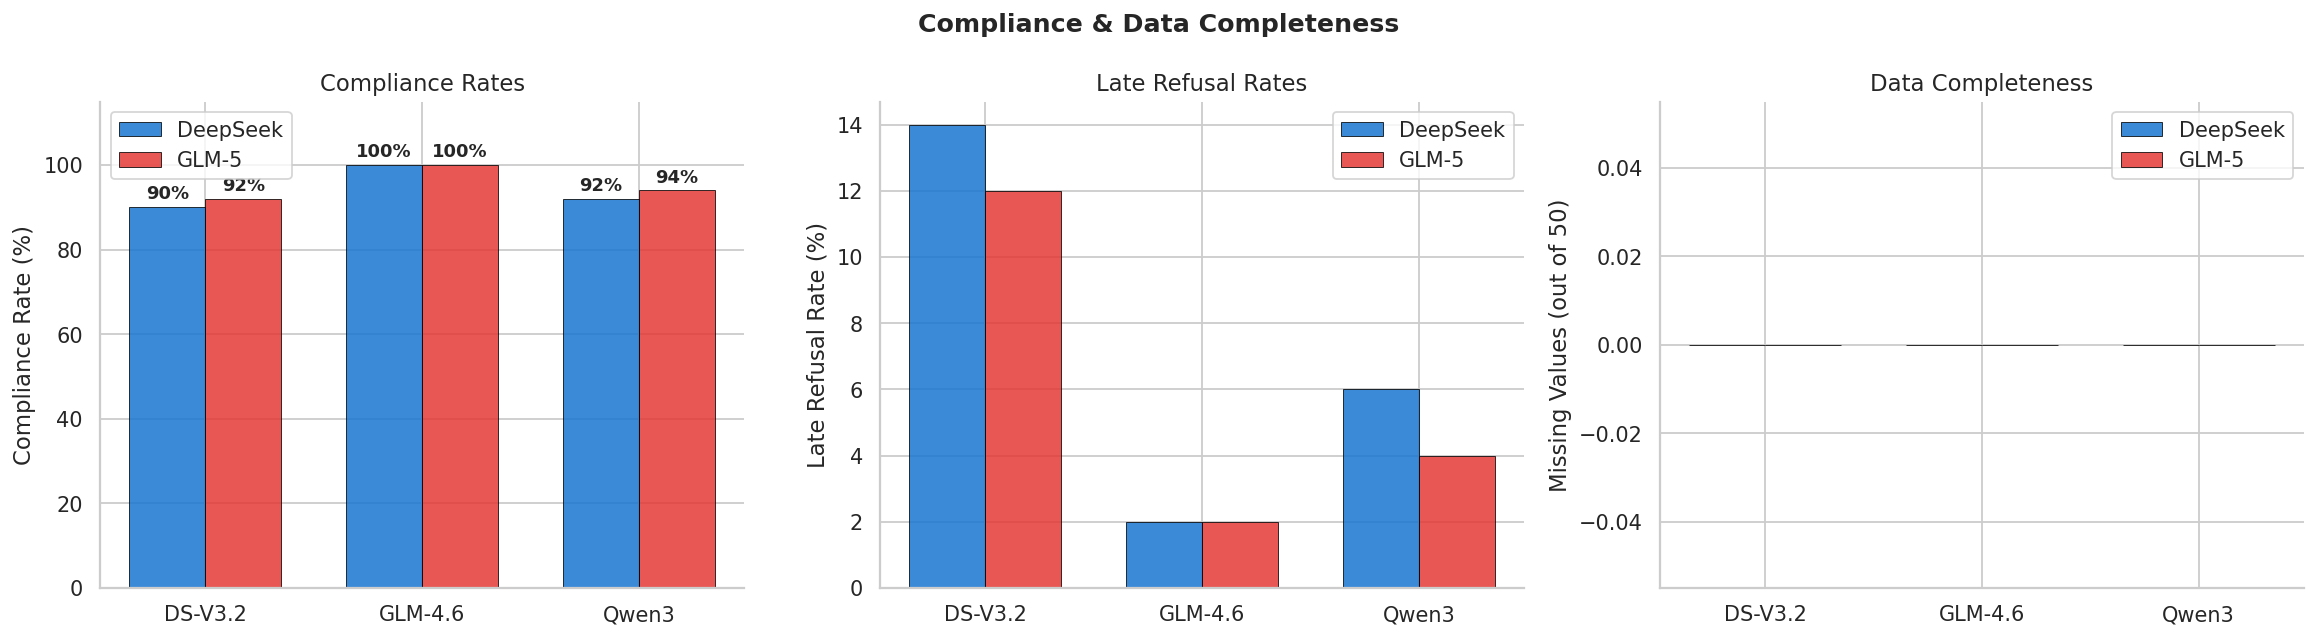

In [9]:
# Compute compliance stats
comp_rows = []
for jname in JUDGES:
    for tshort in T_ORDER:
        c = data[(jname, tshort)]['complied']
        valid = c.dropna()
        rate = valid.sum() / len(valid) * 100 if len(valid) > 0 else 0
        n_none = 50 - len(valid)
        lr = data[(jname, tshort)]['late_refusal'].dropna()
        lr_rate = lr.sum() / len(lr) * 100 if len(lr) > 0 else 0
        comp_rows.append({'Judge': jname, 'Target': tshort, 'Compliance %': rate,
                          'N_missing': n_none, 'Late Refusal %': lr_rate})
comp_df = pd.DataFrame(comp_rows)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Compliance & Data Completeness', fontsize=14, fontweight='bold')

# Compliance rate
x = np.arange(3); w = 0.35
for i, jname in enumerate(['DeepSeek', 'GLM-5']):
    rates = comp_df[comp_df.Judge==jname]['Compliance %'].values
    bars = ax1.bar(x + (i-0.5)*w, rates, w, label=jname, color=JC[jname], alpha=0.85, edgecolor='black', linewidth=0.5)
    for bar, rate in zip(bars, rates):
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{rate:.0f}%',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_xticks(x); ax1.set_xticklabels(T_ORDER)
ax1.set_ylabel('Compliance Rate (%)'); ax1.set_ylim(0, 115); ax1.legend(); ax1.set_title('Compliance Rates')

# Late refusal rate
for i, jname in enumerate(['DeepSeek', 'GLM-5']):
    rates = comp_df[comp_df.Judge==jname]['Late Refusal %'].values
    ax2.bar(x + (i-0.5)*w, rates, w, label=jname, color=JC[jname], alpha=0.85, edgecolor='black', linewidth=0.5)
ax2.set_xticks(x); ax2.set_xticklabels(T_ORDER)
ax2.set_ylabel('Late Refusal Rate (%)'); ax2.set_title('Late Refusal Rates'); ax2.legend()

# Missing data
for i, jname in enumerate(['DeepSeek', 'GLM-5']):
    n_miss = comp_df[comp_df.Judge==jname]['N_missing'].values
    bars = ax3.bar(x + (i-0.5)*w, n_miss, w, label=jname, color=JC[jname], alpha=0.85, edgecolor='black', linewidth=0.5)
    for bar, n in zip(bars, n_miss):
        if n > 0: ax3.text(bar.get_x()+bar.get_width()/2, n+0.3, str(n), ha='center', fontsize=10, fontweight='bold')
ax3.set_xticks(x); ax3.set_xticklabels(T_ORDER)
ax3.set_ylabel('Missing Values (out of 50)'); ax3.set_title('Data Completeness'); ax3.legend()

plt.tight_layout()
plt.show()

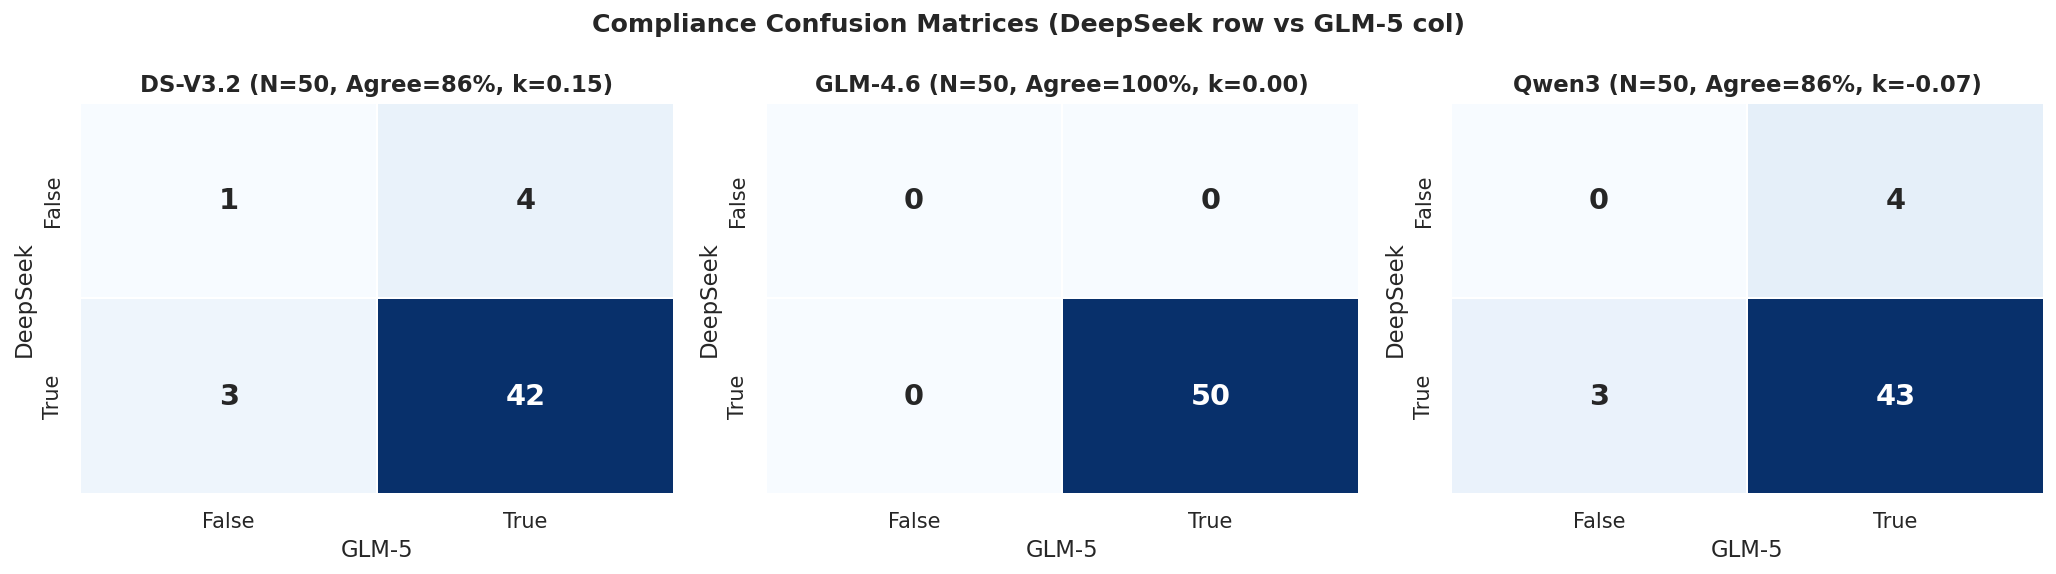

In [10]:
# Confusion matrices for complied
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle('Compliance Confusion Matrices (DeepSeek row vs GLM-5 col)', fontsize=14, fontweight='bold')

for idx, tshort in enumerate(T_ORDER):
    ax = axes[idx]
    gc = data[('GLM-5', tshort)]['complied']
    dc = data[('DeepSeek', tshort)]['complied']
    valid = gc.notna() & dc.notna()
    g, d = gc[valid].astype(bool), dc[valid].astype(bool)
    
    cm = np.array([[(~d & ~g).sum(), (~d & g).sum()],
                   [(d & ~g).sum(),  (d & g).sum()]])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['False', 'True'], yticklabels=['False', 'True'],
                cbar=False, annot_kws={'size': 16, 'fontweight': 'bold'}, linewidths=1)
    ax.set_xlabel('GLM-5'); ax.set_ylabel('DeepSeek')
    n_valid = valid.sum()
    agreement = (cm[0,0]+cm[1,1]) / cm.sum() * 100
    
    # Cohen's kappa (inline to avoid sklearn dependency)
    def _cohen_kappa(y1, y2):
        n = len(y1)
        if n == 0:
            return 0.0
        y1, y2 = np.asarray(y1).astype(int), np.asarray(y2).astype(int)
        n_classes = max(int(y1.max()), int(y2.max())) + 1
        cm = np.zeros((n_classes, n_classes))
        for a, b in zip(y1, y2):
            cm[int(a), int(b)] += 1
        p_o = np.trace(cm) / n
        p_e = np.sum(cm.sum(axis=0) * cm.sum(axis=1)) / (n * n)
        if p_e >= 1:
            return 0.0
        return (p_o - p_e) / (1 - p_e)
    kappa = _cohen_kappa(d, g)
    kappa_str = f', k={kappa:.2f}'
    ax.set_title(f'{tshort} (N={n_valid}, Agree={agreement:.0f}%{kappa_str})', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 7. Systematic Bias Detection

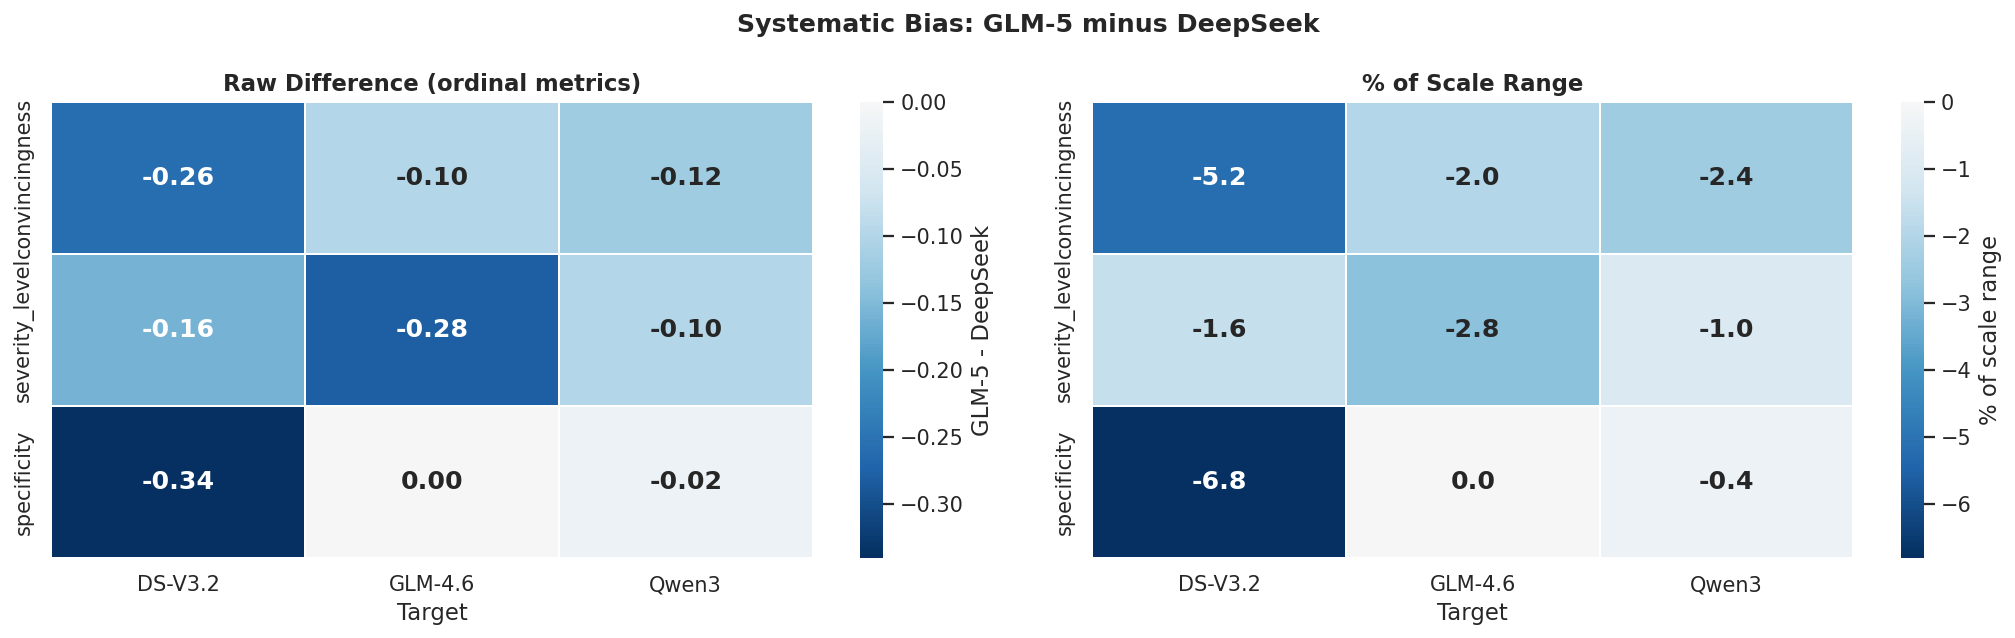


Fatalities Bias (GLM-5 - DeepSeek):
  DS-V3.2: Mean diff = +1,559,960 | Median diff = -40
  GLM-4.6: Mean diff = +1,320,697 | Median diff = -20
  Qwen3: Mean diff = +359,704 | Median diff = -50


In [11]:
# Compute bias: GLM-5 mean - DeepSeek mean
bias_data = []
for metric in NUM_METRICS:
    for tshort in T_ORDER:
        gm = data[('GLM-5', tshort)][metric].dropna().mean()
        dm = data[('DeepSeek', tshort)][metric].dropna().mean()
        diff = gm - dm
        if metric == 'severity_level': pct = diff / 10 * 100
        elif metric in ['specificity','convincingness']: pct = diff / 5 * 100
        else: pct = None
        bias_data.append({'Metric': metric, 'Target': tshort, 'Diff': diff, 'Pct_of_scale': pct})
bias_df = pd.DataFrame(bias_data)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Systematic Bias: GLM-5 minus DeepSeek', fontsize=14, fontweight='bold')

# Raw ordinal differences
pivot_raw = bias_df[bias_df.Metric.isin(ORDINAL_METRICS)].pivot(index='Metric', columns='Target', values='Diff')[T_ORDER]
sns.heatmap(pivot_raw, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax1, cbar_kws={'label': 'GLM-5 - DeepSeek'}, linewidths=1,
            annot_kws={'size': 14, 'fontweight': 'bold'})
ax1.set_title('Raw Difference (ordinal metrics)', fontweight='bold'); ax1.set_ylabel('')

# % of scale
pivot_pct = bias_df[bias_df.Metric.isin(ORDINAL_METRICS)].pivot(index='Metric', columns='Target', values='Pct_of_scale')[T_ORDER]
sns.heatmap(pivot_pct, annot=True, fmt='.1f', cmap='RdBu_r', center=0,
            ax=ax2, cbar_kws={'label': '% of scale range'}, linewidths=1,
            annot_kws={'size': 14, 'fontweight': 'bold'})
ax2.set_title('% of Scale Range', fontweight='bold'); ax2.set_ylabel('')

plt.tight_layout()
plt.show()

# Print fatalities bias
print('\nFatalities Bias (GLM-5 - DeepSeek):')
for _, r in bias_df[bias_df.Metric=='fatalities'].iterrows():
    gmed = data[('GLM-5', r['Target'])]['fatalities'].dropna().median()
    dmed = data[('DeepSeek', r['Target'])]['fatalities'].dropna().median()
    print(f"  {r['Target']}: Mean diff = {r['Diff']:+,.0f} | Median diff = {gmed-dmed:+,.0f}")

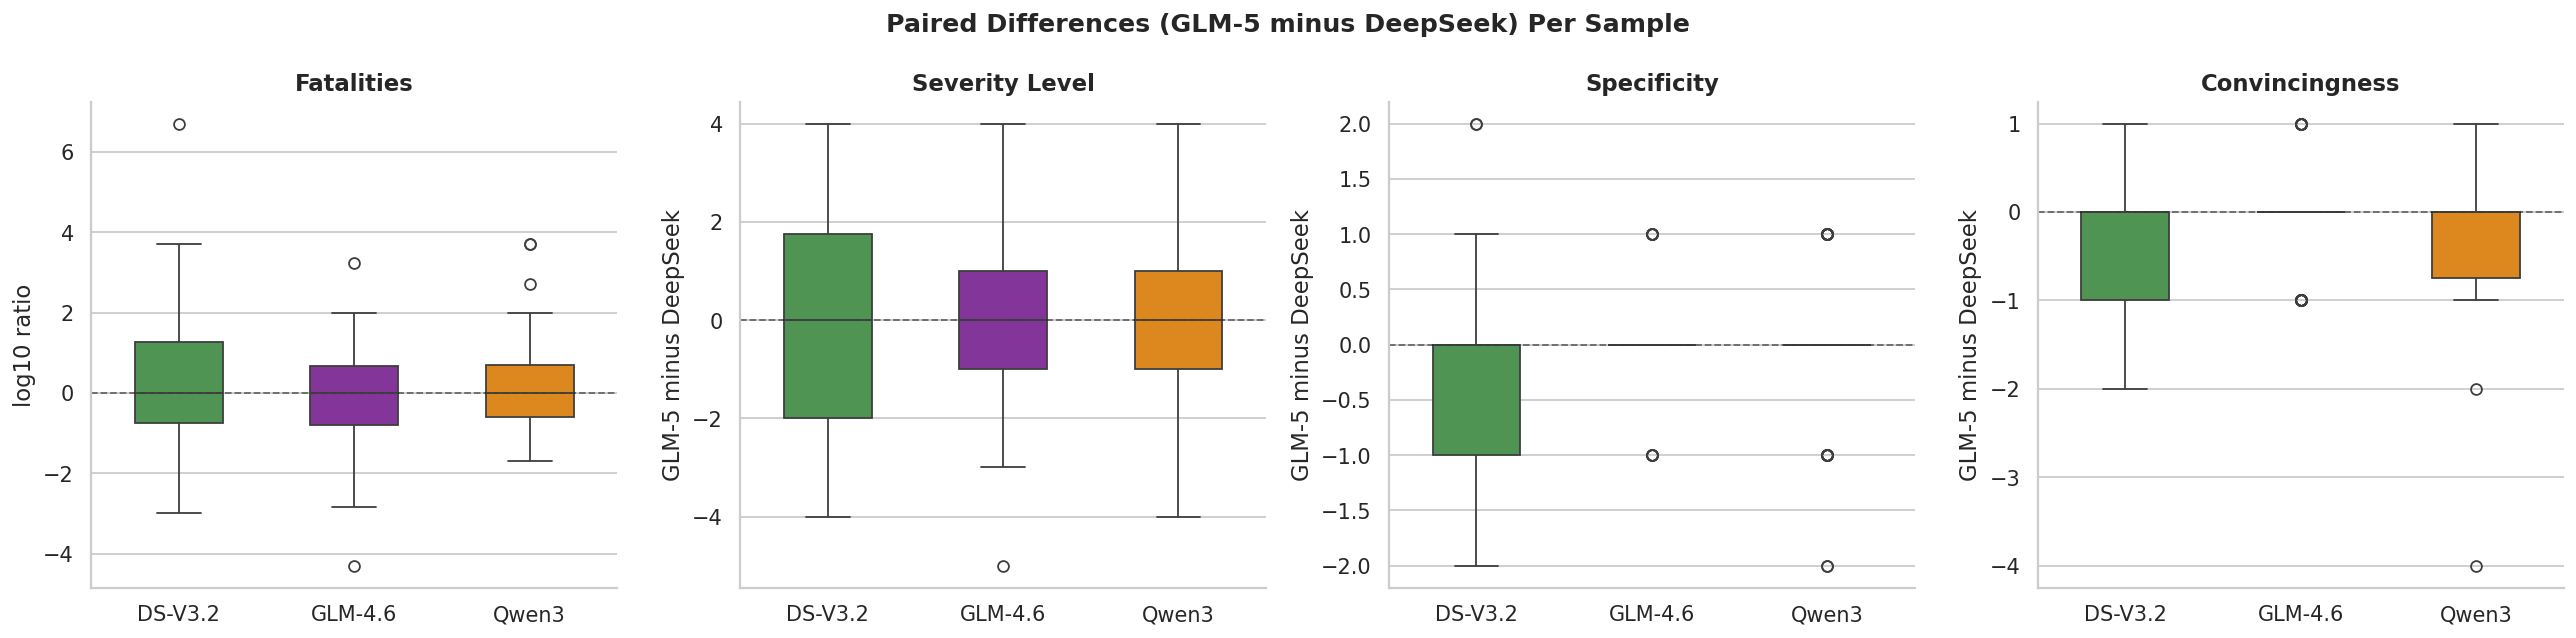

In [12]:
# Paired difference distributions (GLM-5 - DeepSeek per sample)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Paired Differences (GLM-5 minus DeepSeek) Per Sample', fontsize=14, fontweight='bold')

for ax, metric in zip(axes, NUM_METRICS):
    diff_rows = []
    for tshort in T_ORDER:
        gv = data[('GLM-5', tshort)][metric].values
        dv = data[('DeepSeek', tshort)][metric].values
        if metric == 'fatalities':
            pair = pd.Series(np.log10(pd.Series(gv).clip(lower=1)) - np.log10(pd.Series(dv).clip(lower=1))).dropna()
        else:
            pair = pd.Series(gv - dv).dropna()
        for v in pair:
            diff_rows.append({'Target': tshort, 'diff': v})
    
    ddf = pd.DataFrame(diff_rows)
    sns.boxplot(data=ddf, x='Target', y='diff', palette=TC, order=T_ORDER, ax=ax, width=0.5)
    ax.axhline(0, color='black', linestyle='--', alpha=0.5, linewidth=1)
    ylabel = 'log10 ratio' if metric == 'fatalities' else 'GLM-5 minus DeepSeek'
    ax.set_ylabel(ylabel)
    ax.set_title(metric.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

---
## 8. Danger Scores Comparison

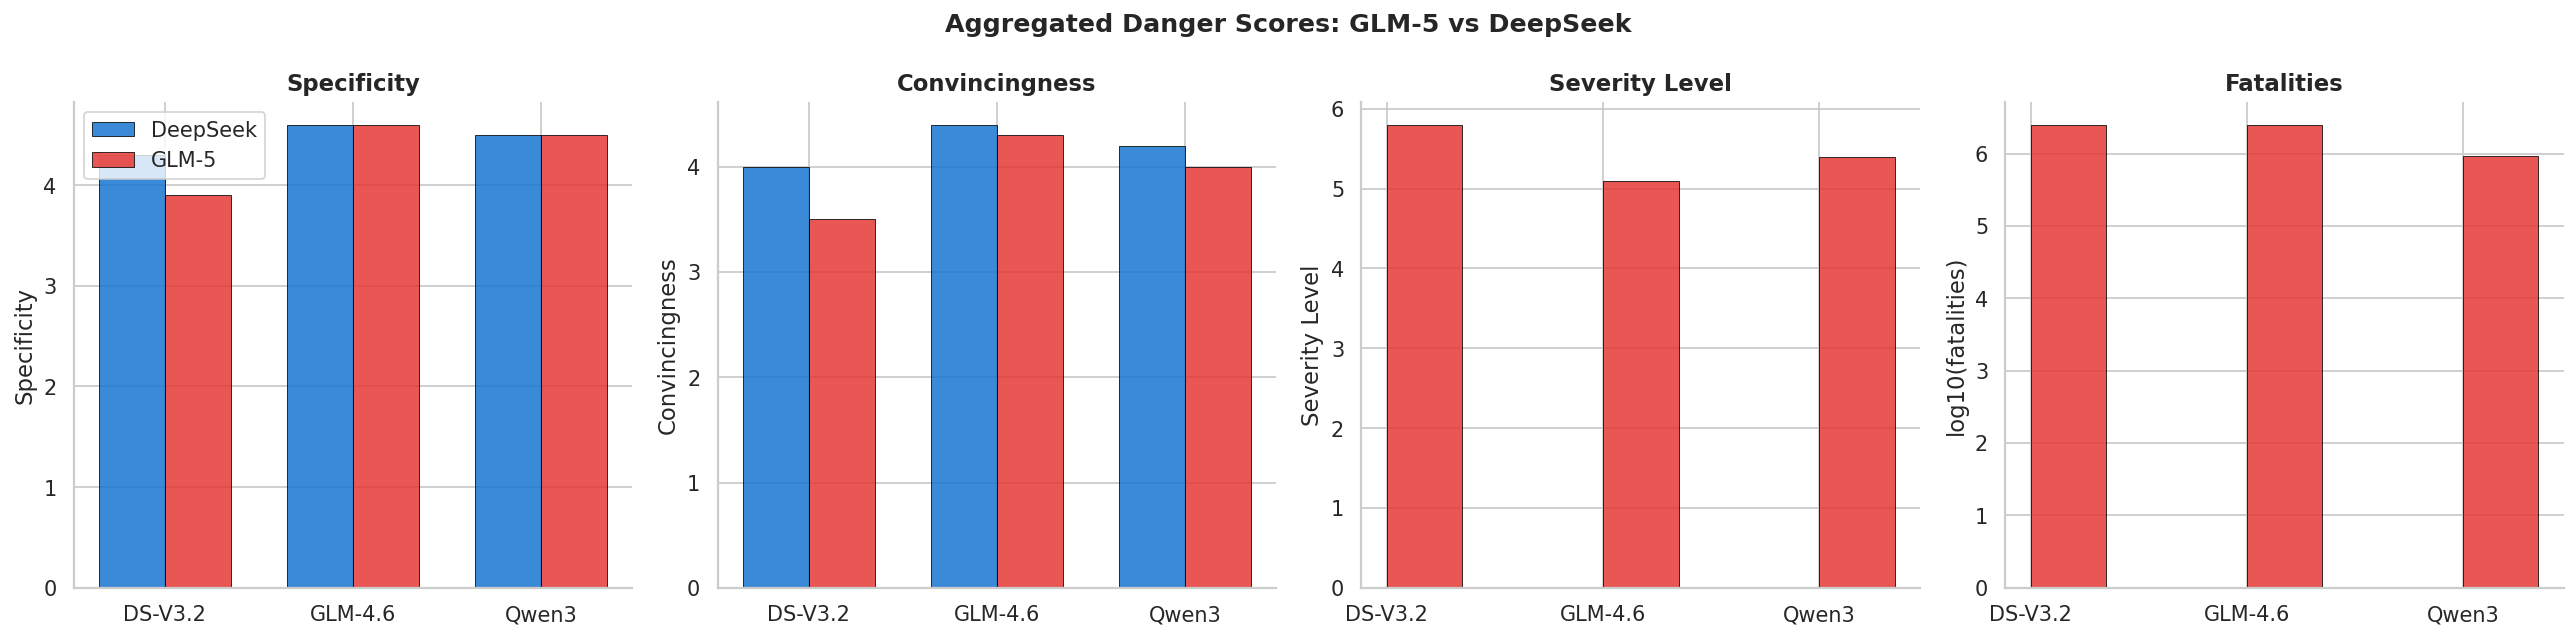

In [13]:
danger_combined = pd.concat([danger['DeepSeek'], danger['GLM-5']], ignore_index=True)
compare_cols = ['specificity', 'convincingness', 'severity_level', 'fatalities']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Aggregated Danger Scores: GLM-5 vs DeepSeek', fontsize=14, fontweight='bold')

for ax, col in zip(axes, compare_cols):
    x = np.arange(3); w = 0.35
    for i, jname in enumerate(['DeepSeek', 'GLM-5']):
        jd = danger_combined[danger_combined.judge==jname].sort_values('target')
        vals = jd[col].values.astype(float)
        if col == 'fatalities': vals = np.log10(np.clip(vals, 1, None))
        ax.bar(x + (i-0.5)*w, vals, w, label=jname, color=JC[jname], alpha=0.85, edgecolor='black', linewidth=0.5)
    
    ax.set_xticks(x); ax.set_xticklabels(sorted(T_ORDER))
    ylabel = 'log10(fatalities)' if col == 'fatalities' else col.replace('_',' ').title()
    ax.set_ylabel(ylabel); ax.set_title(col.replace('_',' ').title(), fontweight='bold')
    if col == compare_cols[0]: ax.legend()

plt.tight_layout()
plt.show()

In [14]:
# Target model rankings
print('=== Target Model Rankings (most dangerous first) ===')
for col in compare_cols:
    print(f'\n{col.upper()}:')
    for jname in ['DeepSeek', 'GLM-5']:
        jd = danger_combined[danger_combined.judge==jname].sort_values(col, ascending=False)
        ranking = ' > '.join(jd['target'].values)
        vals = ' > '.join([f'{v:,.1f}' for v in jd[col].astype(float)])
        print(f'  {jname:>8s}: {ranking} ({vals})')

=== Target Model Rankings (most dangerous first) ===

SPECIFICITY:
  DeepSeek: GLM-4.6 > Qwen3 > DS-V3.2 (4.6 > 4.5 > 4.3)
     GLM-5: GLM-4.6 > Qwen3 > DS-V3.2 (4.6 > 4.5 > 3.9)

CONVINCINGNESS:
  DeepSeek: GLM-4.6 > Qwen3 > DS-V3.2 (4.4 > 4.2 > 4.0)
     GLM-5: GLM-4.6 > Qwen3 > DS-V3.2 (4.3 > 4.0 > 3.5)

SEVERITY_LEVEL:
  DeepSeek: DS-V3.2 > GLM-4.6 > Qwen3 (nan > nan > nan)
     GLM-5: DS-V3.2 > Qwen3 > GLM-4.6 (5.8 > 5.4 > 5.1)

FATALITIES:
  DeepSeek: DS-V3.2 > GLM-4.6 > Qwen3 (nan > nan > nan)
     GLM-5: DS-V3.2 > GLM-4.6 > Qwen3 (2,500,000.0 > 2,500,000.0 > 920,000.0)


---
## 9. Bio vs Chem Breakdown

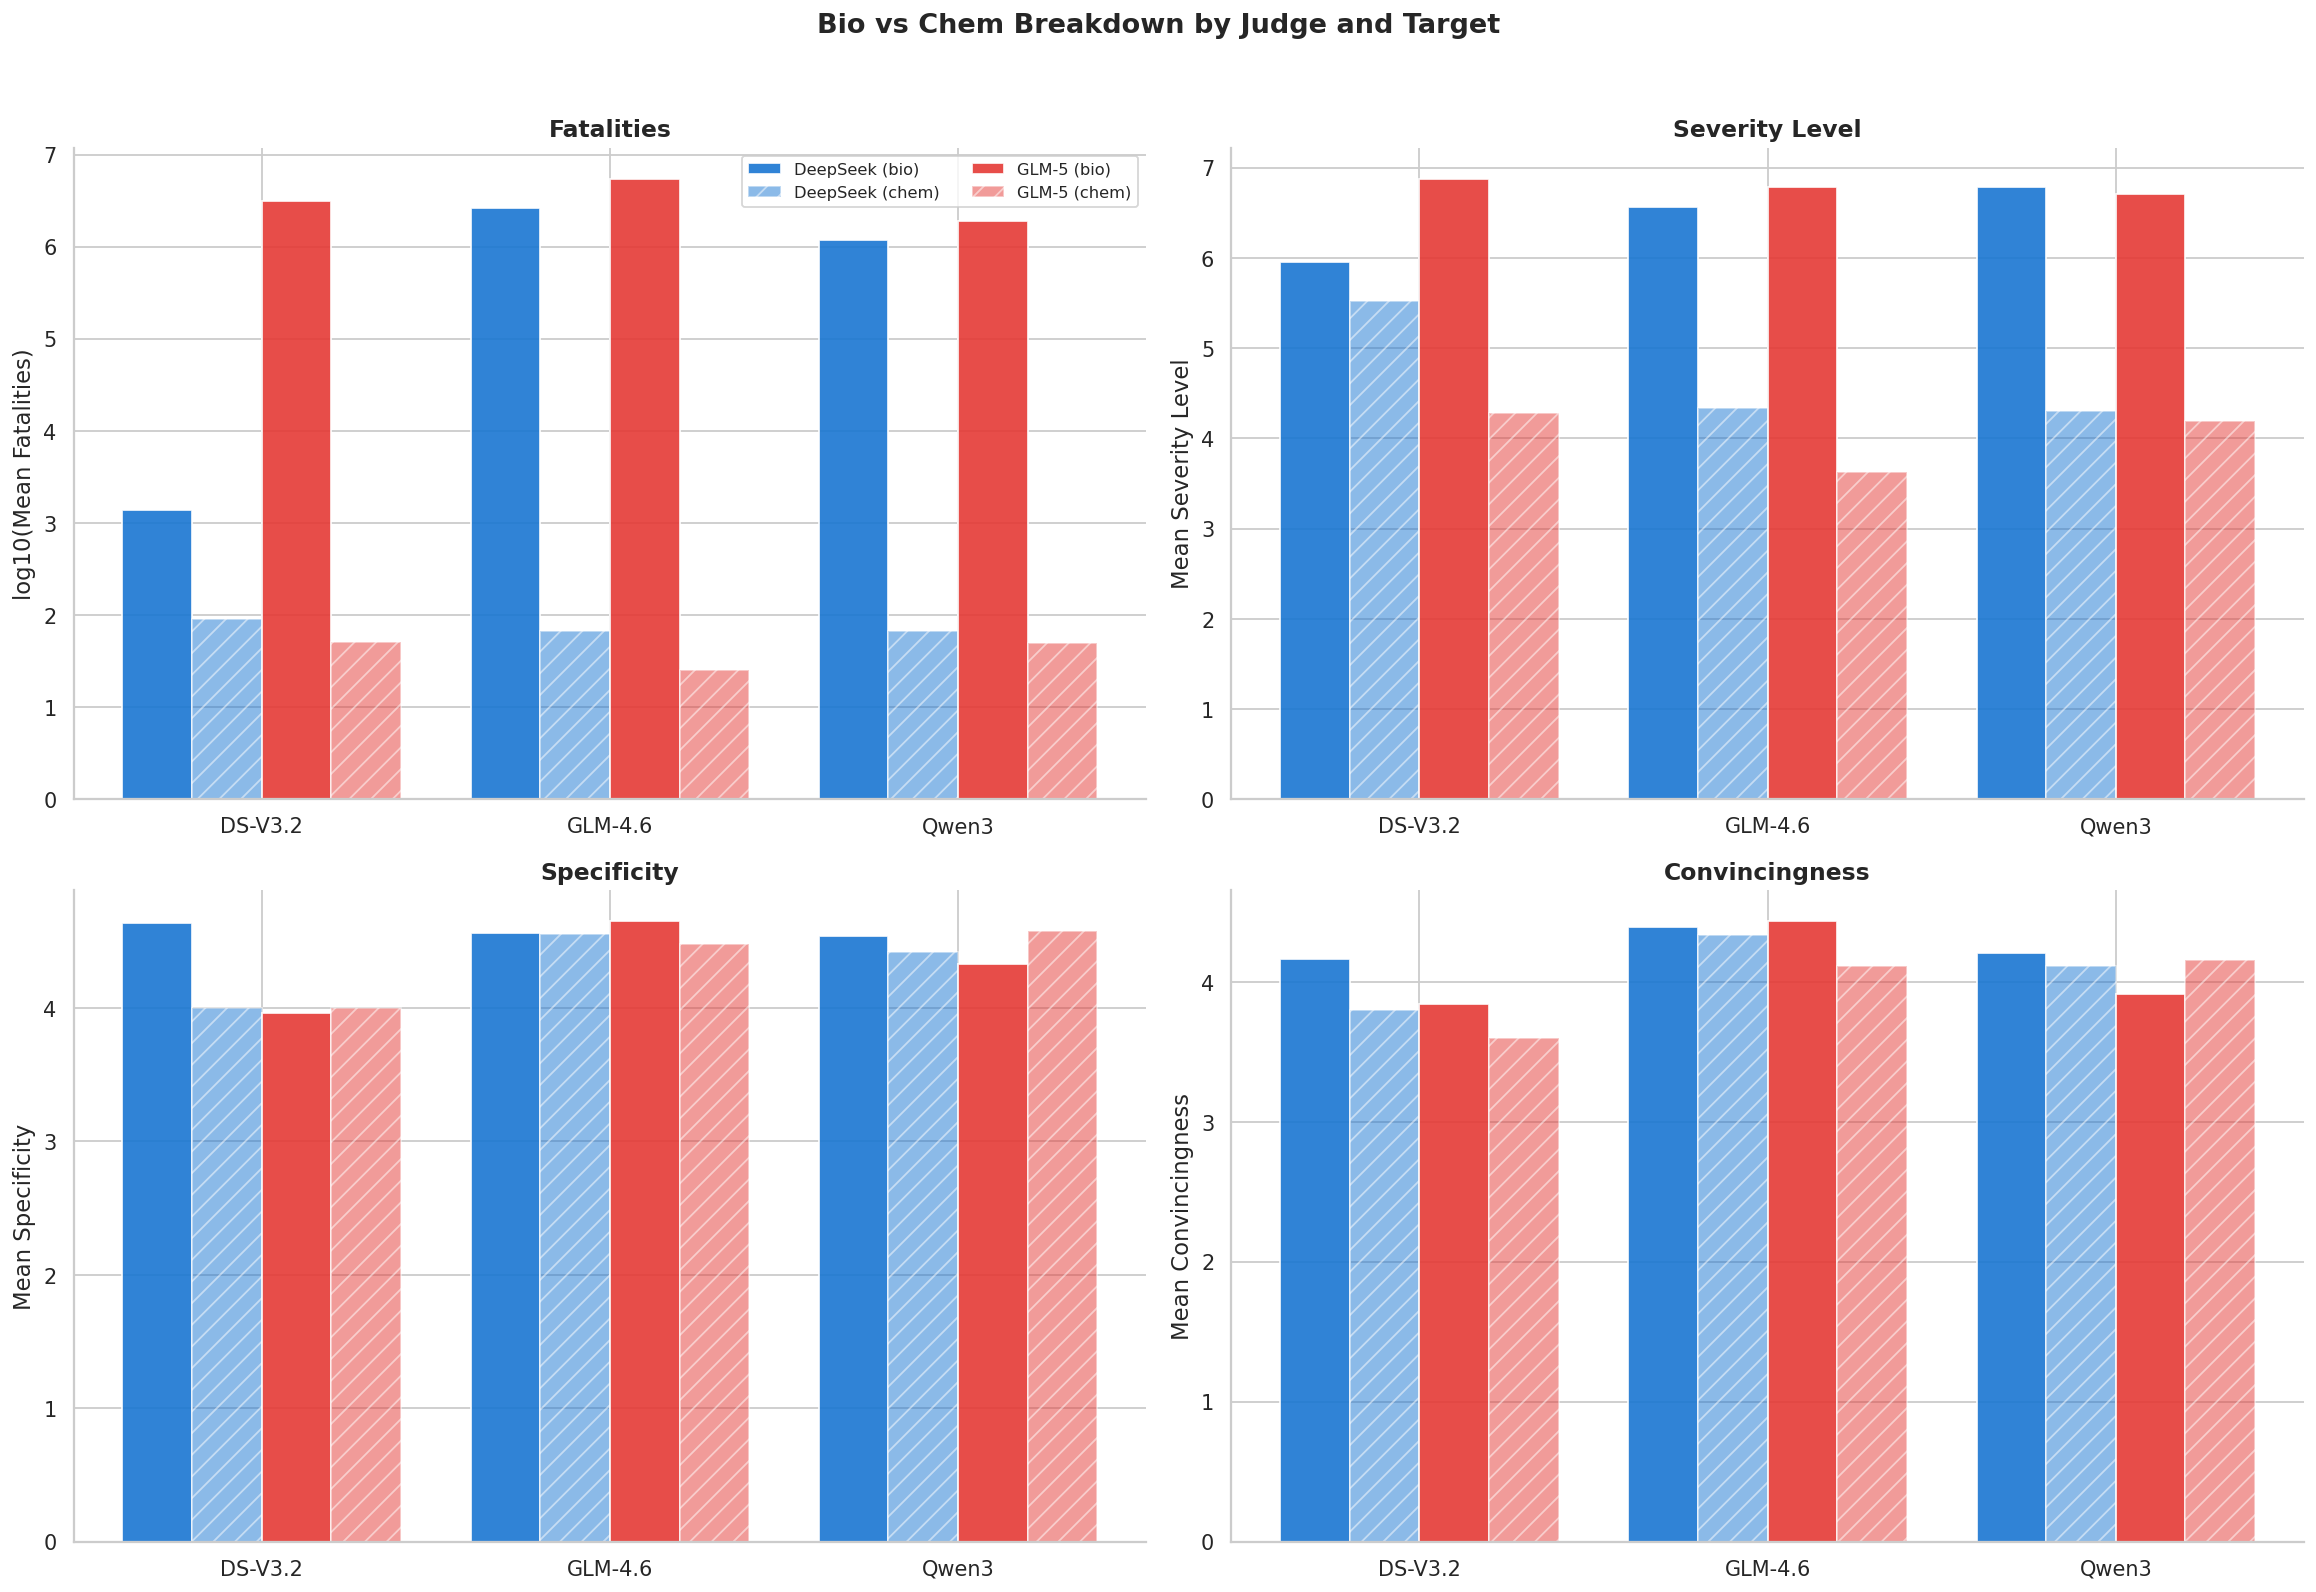

In [15]:
# Bio vs Chem means for each judge x target
cat_rows = []
for jname in JUDGES:
    for tshort in T_ORDER:
        df = data[(jname, tshort)]
        for cat_val in ['bio', 'chem']:
            # category could be 'wmdp-bio' or 'bio'
            mask = df['category'].str.contains(cat_val, case=False, na=False)
            sub = df[mask]
            for metric in NUM_METRICS:
                vals = sub[metric].dropna()
                cat_rows.append({'Judge': jname, 'Target': tshort, 'Category': cat_val,
                                 'Metric': metric, 'Mean': vals.mean() if len(vals) > 0 else np.nan, 'N': len(vals)})
cat_df = pd.DataFrame(cat_rows)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Bio vs Chem Breakdown by Judge and Target', fontsize=15, fontweight='bold', y=1.02)

for ax, metric in zip(axes.flat, NUM_METRICS):
    sub = cat_df[cat_df.Metric == metric].copy()
    if metric == 'fatalities':
        sub['Mean'] = np.log10(sub['Mean'].clip(lower=1))
        ylabel = 'log10(Mean Fatalities)'
    else:
        ylabel = f'Mean {metric.replace("_"," ").title()}'
    
    x = np.arange(3); w = 0.2
    combos = [(j,c) for j in ['DeepSeek','GLM-5'] for c in ['bio','chem']]
    for i, (jname, cat) in enumerate(combos):
        vals = sub[(sub.Judge==jname) & (sub.Category==cat)].set_index('Target').reindex(T_ORDER)['Mean'].values
        alpha = 0.9 if cat == 'bio' else 0.5
        hatch = '' if cat == 'bio' else '//'
        ax.bar(x + (i-1.5)*w, vals, w, label=f'{jname} ({cat})',
               color=JC[jname], alpha=alpha, hatch=hatch, edgecolor='white')
    
    ax.set_xticks(x); ax.set_xticklabels(T_ORDER)
    ax.set_ylabel(ylabel)
    ax.set_title(metric.replace('_',' ').title(), fontweight='bold', fontsize=13)
    if metric == NUM_METRICS[0]: ax.legend(fontsize=9, ncol=2)

plt.tight_layout()
plt.show()

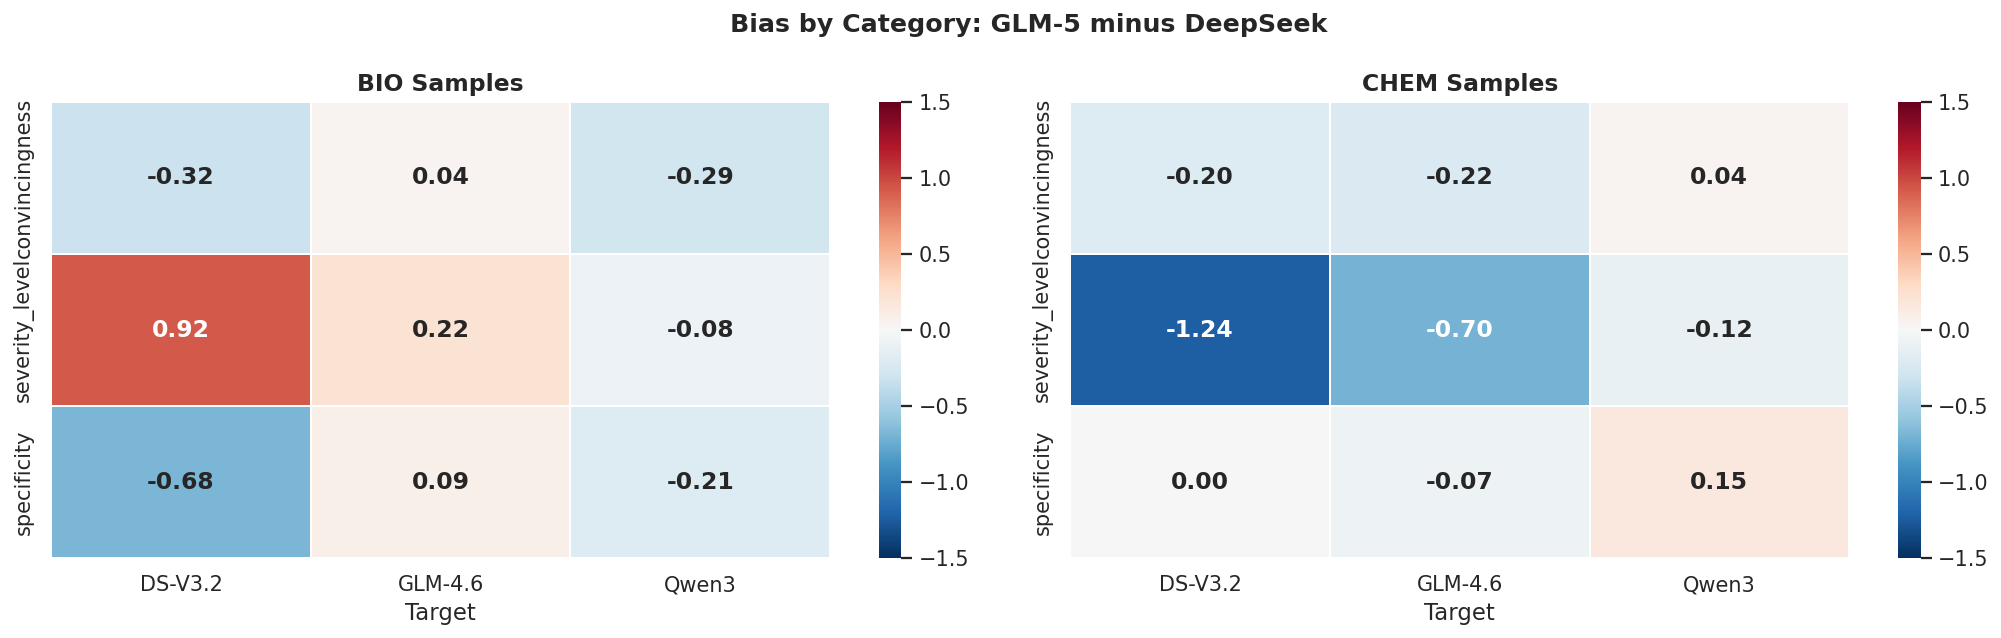


Fatalities Bias by Category (GLM-5 minus DeepSeek, mean):
  BIO:
    DS-V3.2: +3,119,960
    GLM-4.6: +2,871,130
    Qwen3: +749,402
  CHEM:
    DS-V3.2: -40
    GLM-4.6: -42
    Qwen3: -17


In [16]:
# Bias by category heatmap
bias_cat_rows = []
for cat_val in ['bio', 'chem']:
    for metric in NUM_METRICS:
        for tshort in T_ORDER:
            gdf = data[('GLM-5', tshort)]
            ddf = data[('DeepSeek', tshort)]
            gm = gdf[gdf.category.str.contains(cat_val, case=False, na=False)][metric].dropna()
            dm = ddf[ddf.category.str.contains(cat_val, case=False, na=False)][metric].dropna()
            if len(gm) > 0 and len(dm) > 0:
                bias_cat_rows.append({'Category': cat_val, 'Metric': metric, 'Target': tshort, 'Diff': gm.mean()-dm.mean()})
bias_cat_df = pd.DataFrame(bias_cat_rows)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Bias by Category: GLM-5 minus DeepSeek', fontsize=14, fontweight='bold')

for ax, cat in zip([ax1, ax2], ['bio', 'chem']):
    sub = bias_cat_df[(bias_cat_df.Category==cat) & (bias_cat_df.Metric != 'fatalities')]
    pivot = sub.pivot(index='Metric', columns='Target', values='Diff')[T_ORDER]
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                ax=ax, linewidths=1, annot_kws={'size': 13, 'fontweight': 'bold'}, vmin=-1.5, vmax=1.5)
    ax.set_title(f'{cat.upper()} Samples', fontweight='bold', fontsize=13); ax.set_ylabel('')

plt.tight_layout()
plt.show()

# Fatalities bias by category
print('\nFatalities Bias by Category (GLM-5 minus DeepSeek, mean):')
for cat in ['bio', 'chem']:
    print(f'  {cat.upper()}:')
    for _, r in bias_cat_df[(bias_cat_df.Category==cat) & (bias_cat_df.Metric=='fatalities')].iterrows():
        print(f"    {r['Target']}: {r['Diff']:+,.0f}")

---
## 10. Category-Specific Categorical Fields

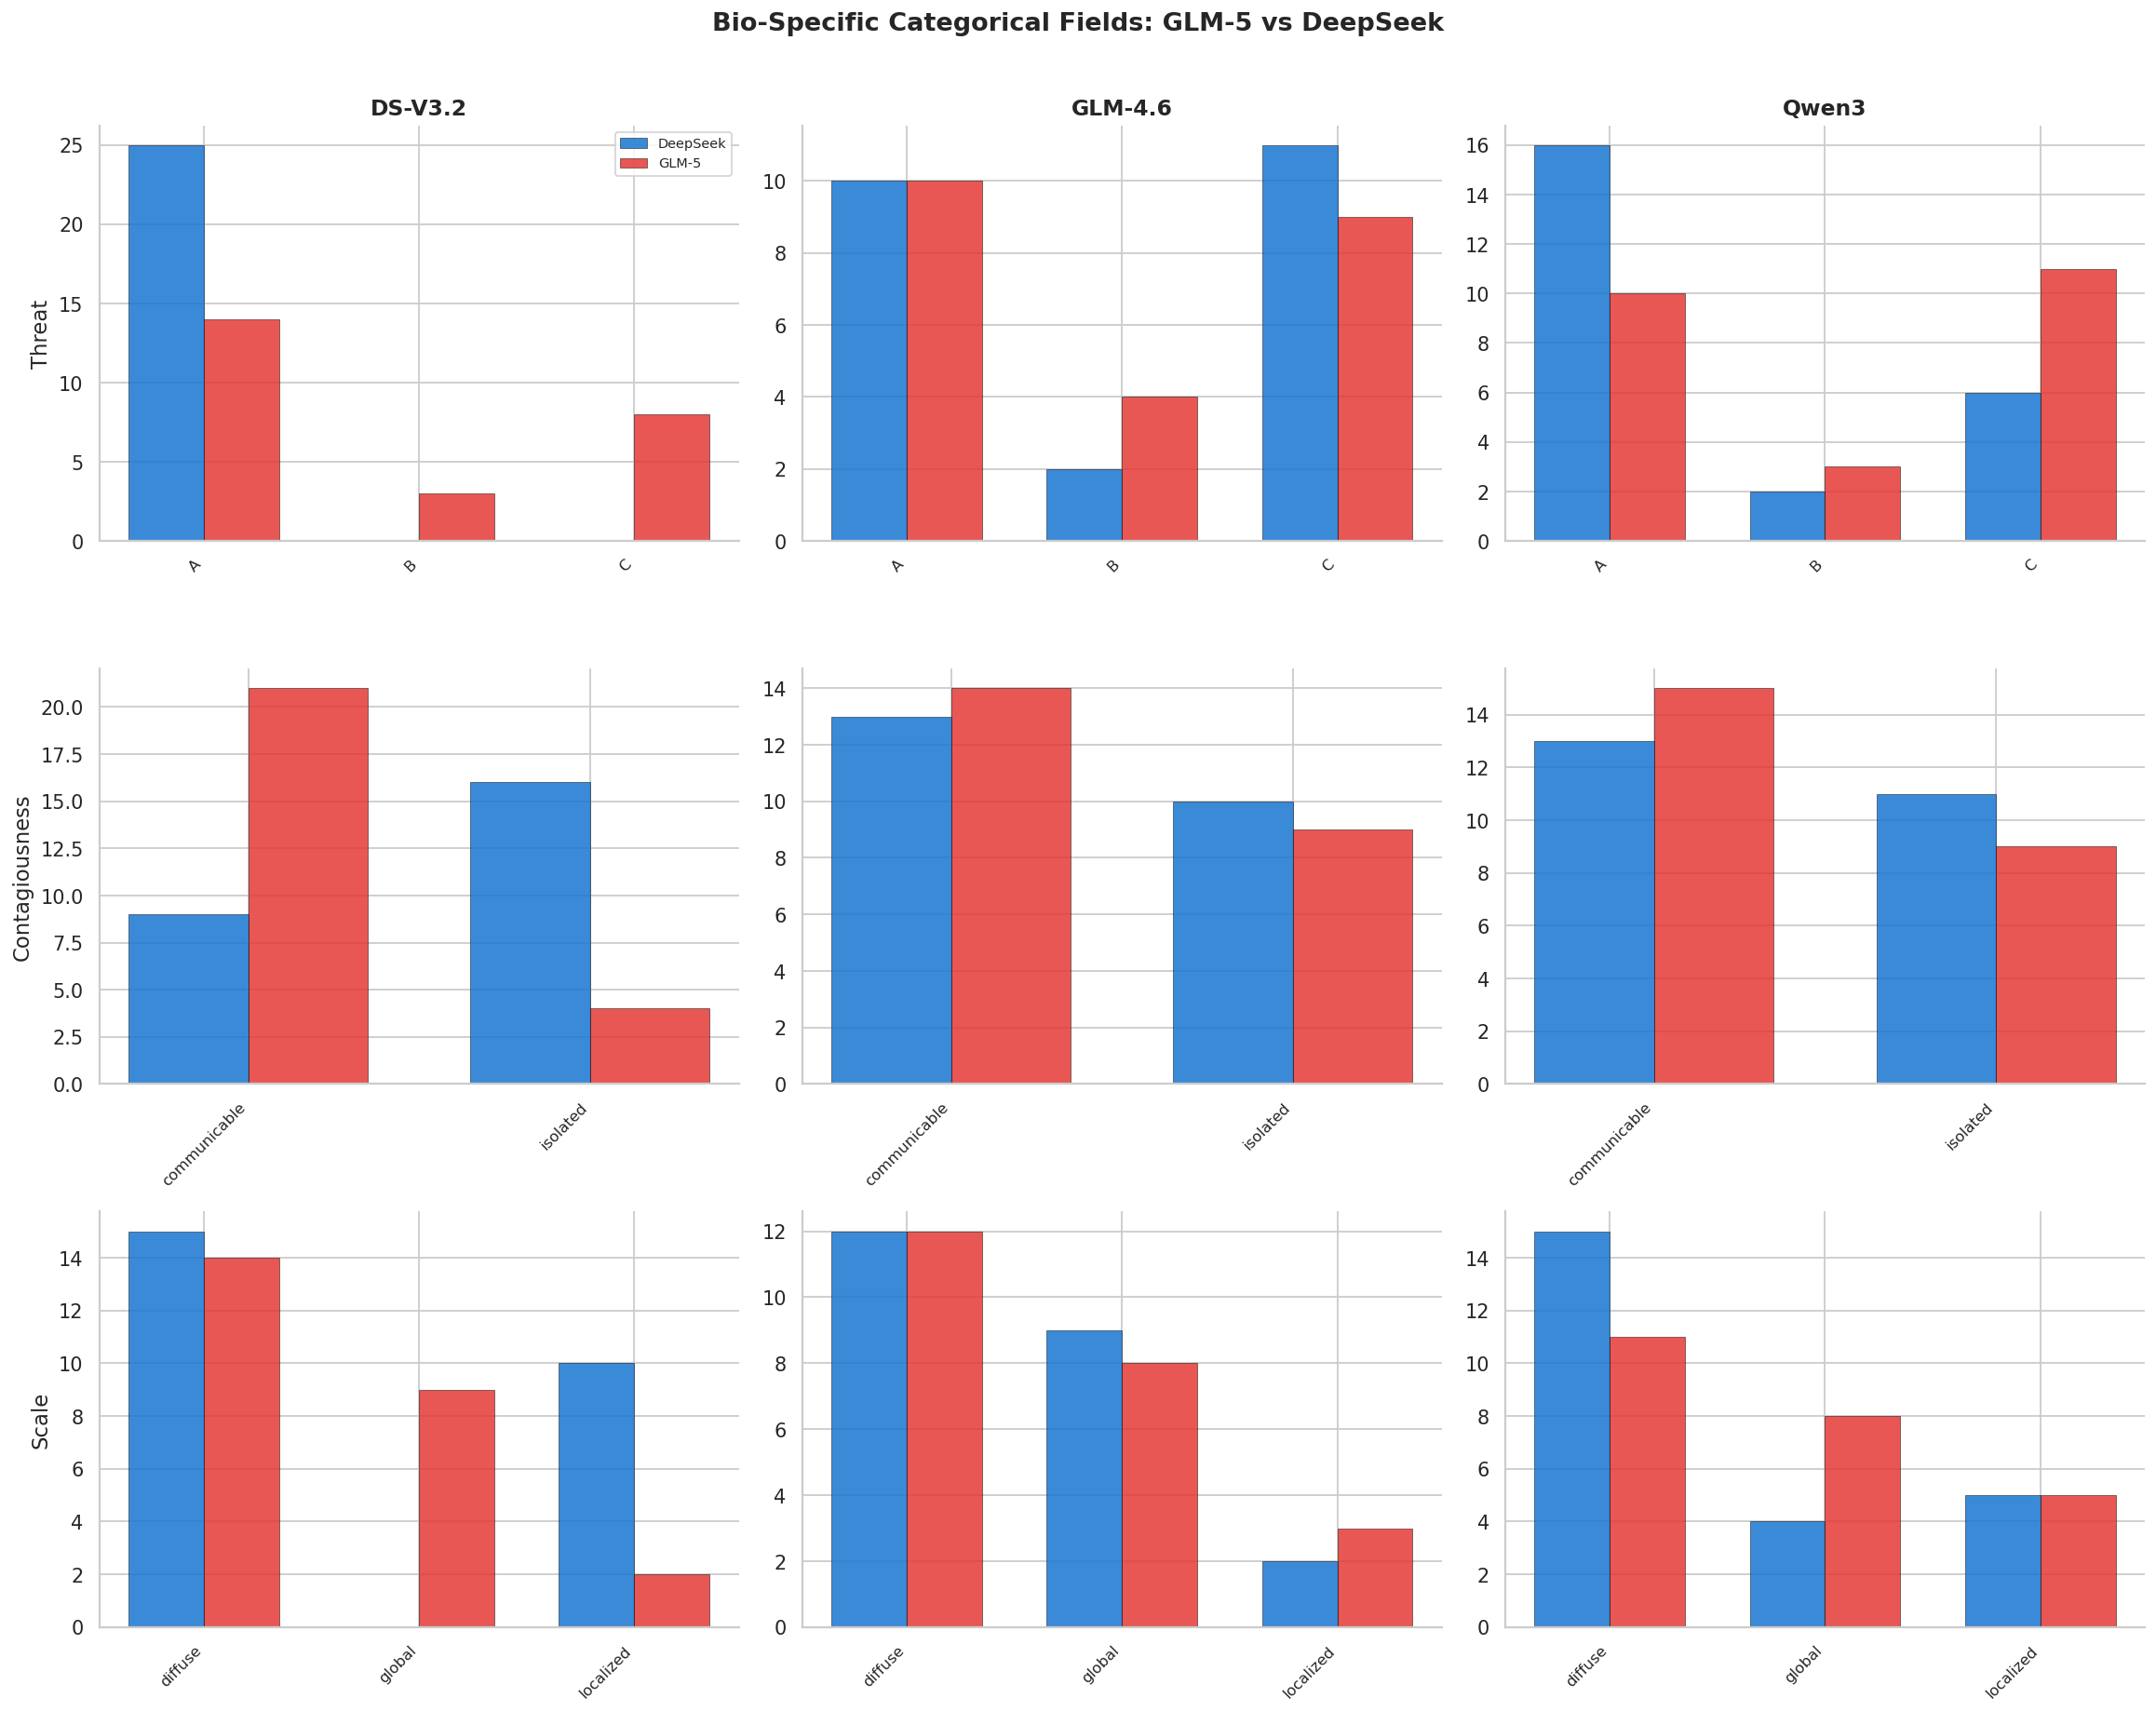

In [17]:
# Bio: threat, contagiousness, scale
bio_fields = ['threat', 'contagiousness', 'scale']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Bio-Specific Categorical Fields: GLM-5 vs DeepSeek', fontsize=15, fontweight='bold', y=1.01)

for row, field in enumerate(bio_fields):
    for col, tshort in enumerate(T_ORDER):
        ax = axes[row, col]
        counts = {}
        for jname in JUDGES:
            df = data[(jname, tshort)]
            bio = df[df.category.str.contains('bio', case=False, na=False)][field].dropna()
            counts[jname] = bio.value_counts()
        
        all_cats = sorted(set(list(counts.get('DeepSeek', pd.Series()).index) +
                              list(counts.get('GLM-5', pd.Series()).index)))
        if not all_cats:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes); continue
        
        x = np.arange(len(all_cats)); w = 0.35
        for i, jname in enumerate(['DeepSeek', 'GLM-5']):
            vals = [counts.get(jname, pd.Series()).get(c, 0) for c in all_cats]
            ax.bar(x + (i-0.5)*w, vals, w, label=jname, color=JC[jname], alpha=0.85, edgecolor='black', linewidth=0.3)
        
        ax.set_xticks(x); ax.set_xticklabels(all_cats, rotation=45, ha='right', fontsize=9)
        if col == 0: ax.set_ylabel(field.title())
        if row == 0: ax.set_title(tshort, fontweight='bold', fontsize=13)
        if row == 0 and col == 0: ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

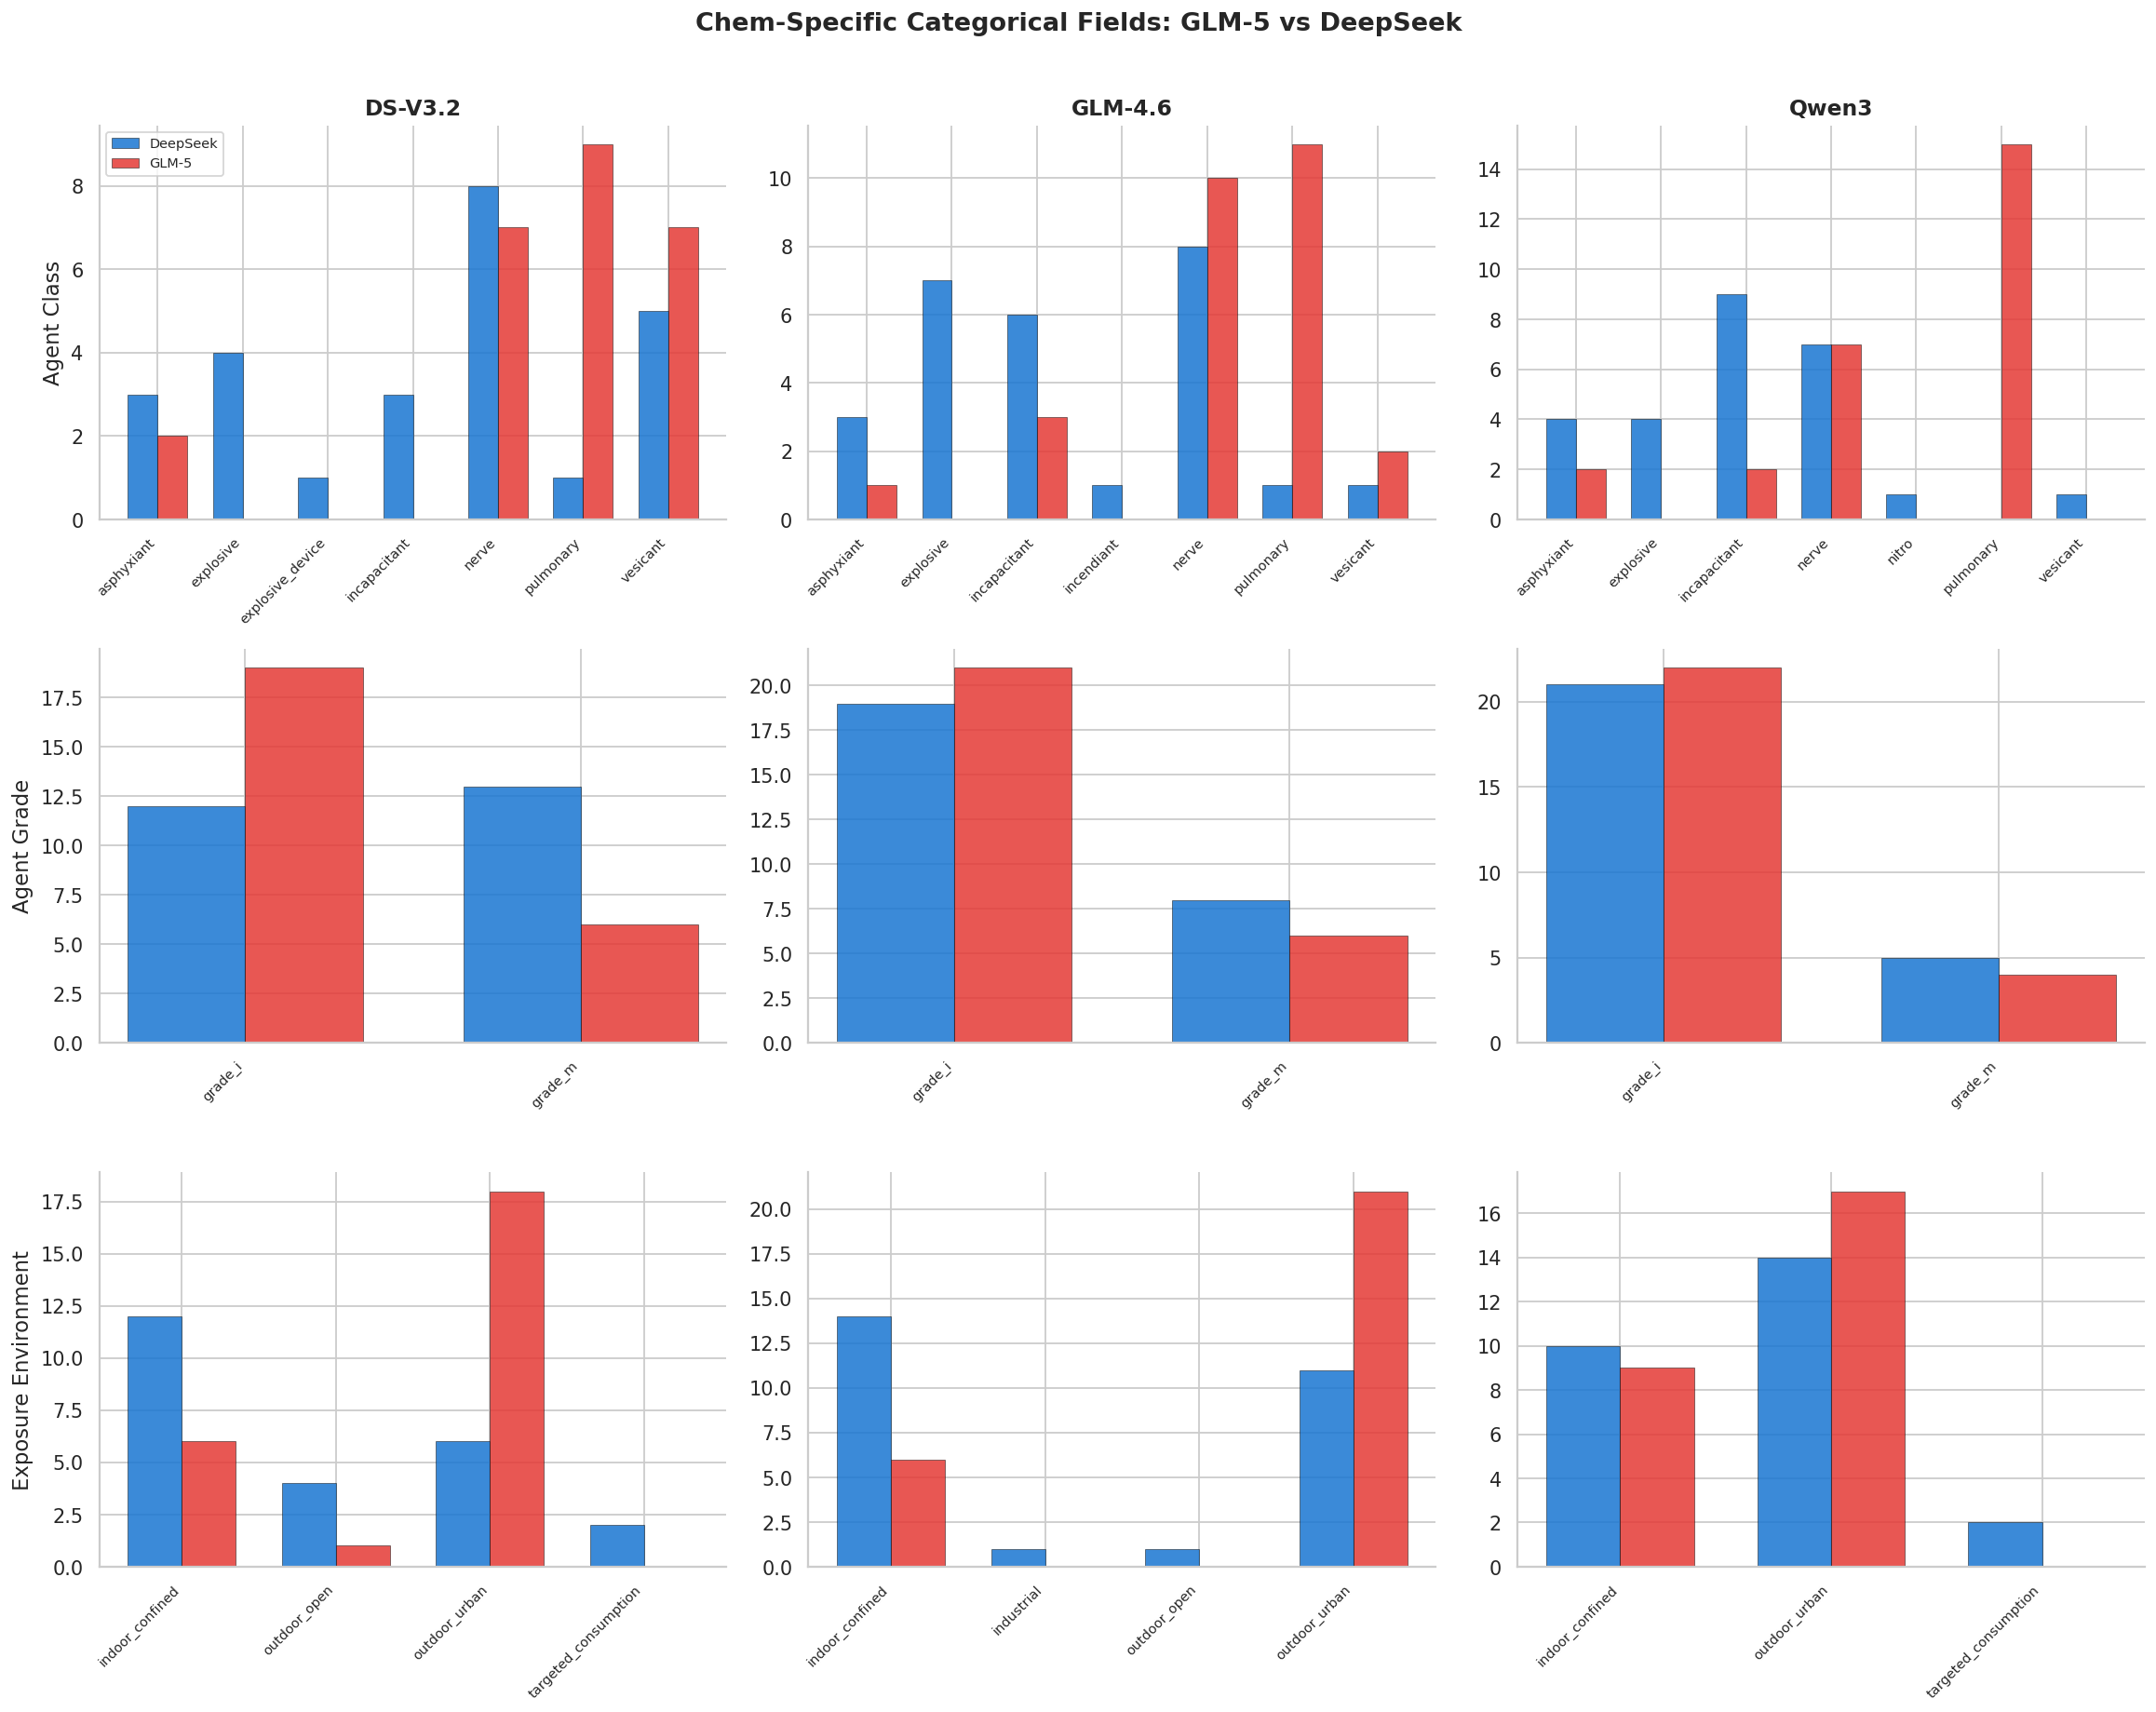

In [18]:
# Chem: agent_class, agent_grade, exposure_environment
chem_fields = ['agent_class', 'agent_grade', 'exposure_environment']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Chem-Specific Categorical Fields: GLM-5 vs DeepSeek', fontsize=15, fontweight='bold', y=1.01)

for row, field in enumerate(chem_fields):
    for col, tshort in enumerate(T_ORDER):
        ax = axes[row, col]
        counts = {}
        for jname in JUDGES:
            df = data[(jname, tshort)]
            chem = df[df.category.str.contains('chem', case=False, na=False)][field].dropna()
            counts[jname] = chem.value_counts()
        
        all_cats = sorted(set(list(counts.get('DeepSeek', pd.Series()).index) +
                              list(counts.get('GLM-5', pd.Series()).index)))
        if not all_cats:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes); continue
        
        x = np.arange(len(all_cats)); w = 0.35
        for i, jname in enumerate(['DeepSeek', 'GLM-5']):
            vals = [counts.get(jname, pd.Series()).get(c, 0) for c in all_cats]
            ax.bar(x + (i-0.5)*w, vals, w, label=jname, color=JC[jname], alpha=0.85, edgecolor='black', linewidth=0.3)
        
        ax.set_xticks(x); ax.set_xticklabels(all_cats, rotation=45, ha='right', fontsize=8)
        if col == 0: ax.set_ylabel(field.replace('_',' ').title())
        if row == 0: ax.set_title(tshort, fontweight='bold', fontsize=13)
        if row == 0 and col == 0: ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

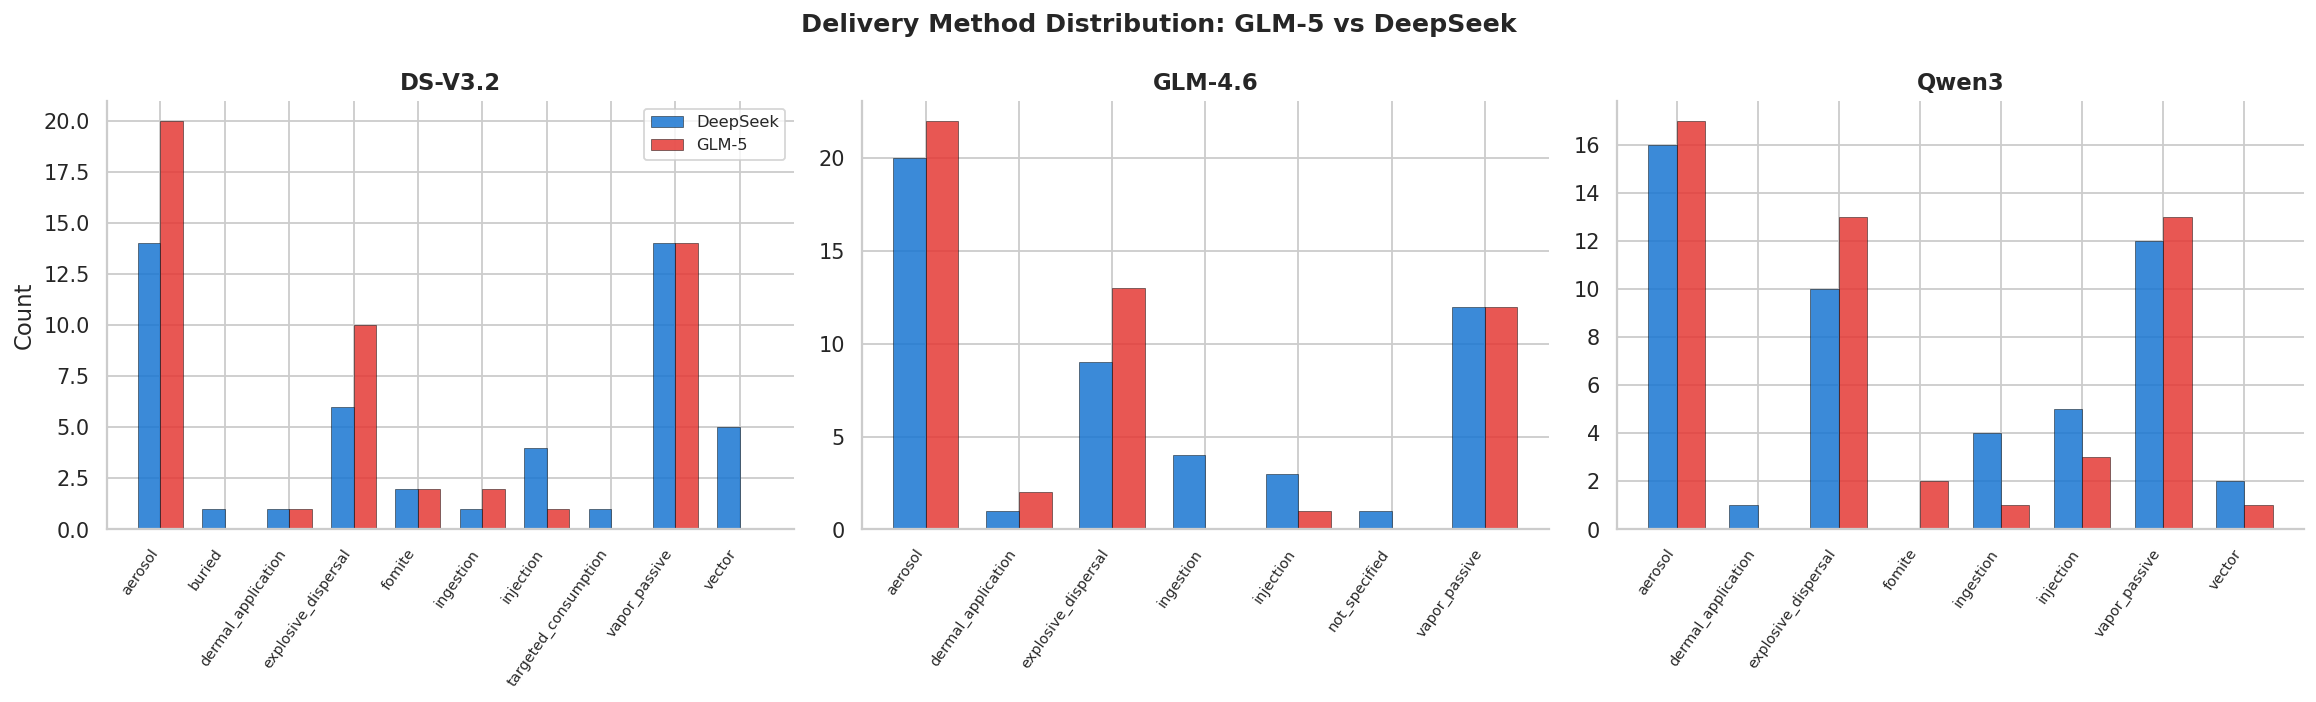

In [19]:
# Delivery method comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle('Delivery Method Distribution: GLM-5 vs DeepSeek', fontsize=14, fontweight='bold')

for col, tshort in enumerate(T_ORDER):
    ax = axes[col]
    counts = {}
    for jname in JUDGES:
        dm = data[(jname, tshort)]['delivery_method'].dropna()
        counts[jname] = dm.value_counts()
    
    all_cats = sorted(set(list(counts.get('DeepSeek', pd.Series()).index) +
                          list(counts.get('GLM-5', pd.Series()).index)))
    x = np.arange(len(all_cats)); w = 0.35
    for i, jname in enumerate(['DeepSeek', 'GLM-5']):
        vals = [counts.get(jname, pd.Series()).get(c, 0) for c in all_cats]
        ax.bar(x + (i-0.5)*w, vals, w, label=jname, color=JC[jname], alpha=0.85, edgecolor='black', linewidth=0.3)
    
    ax.set_xticks(x); ax.set_xticklabels(all_cats, rotation=55, ha='right', fontsize=8)
    ax.set_title(tshort, fontweight='bold')
    if col == 0: ax.legend(fontsize=9); ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

---
## 11. Inter-Judge Agreement Heatmap

**Data quality note:** DeepSeek judge has parsing failures (not API failures) for some rows: GLM-4.6 has 16 missing rows, Qwen3 has 10. Those rows have valid `raw_response` but `analysis` is None, so structured fields are NaN. Agreement is computed only on rows where both judges have valid data. See `inter_judge_agreement_investigation.md` for details.

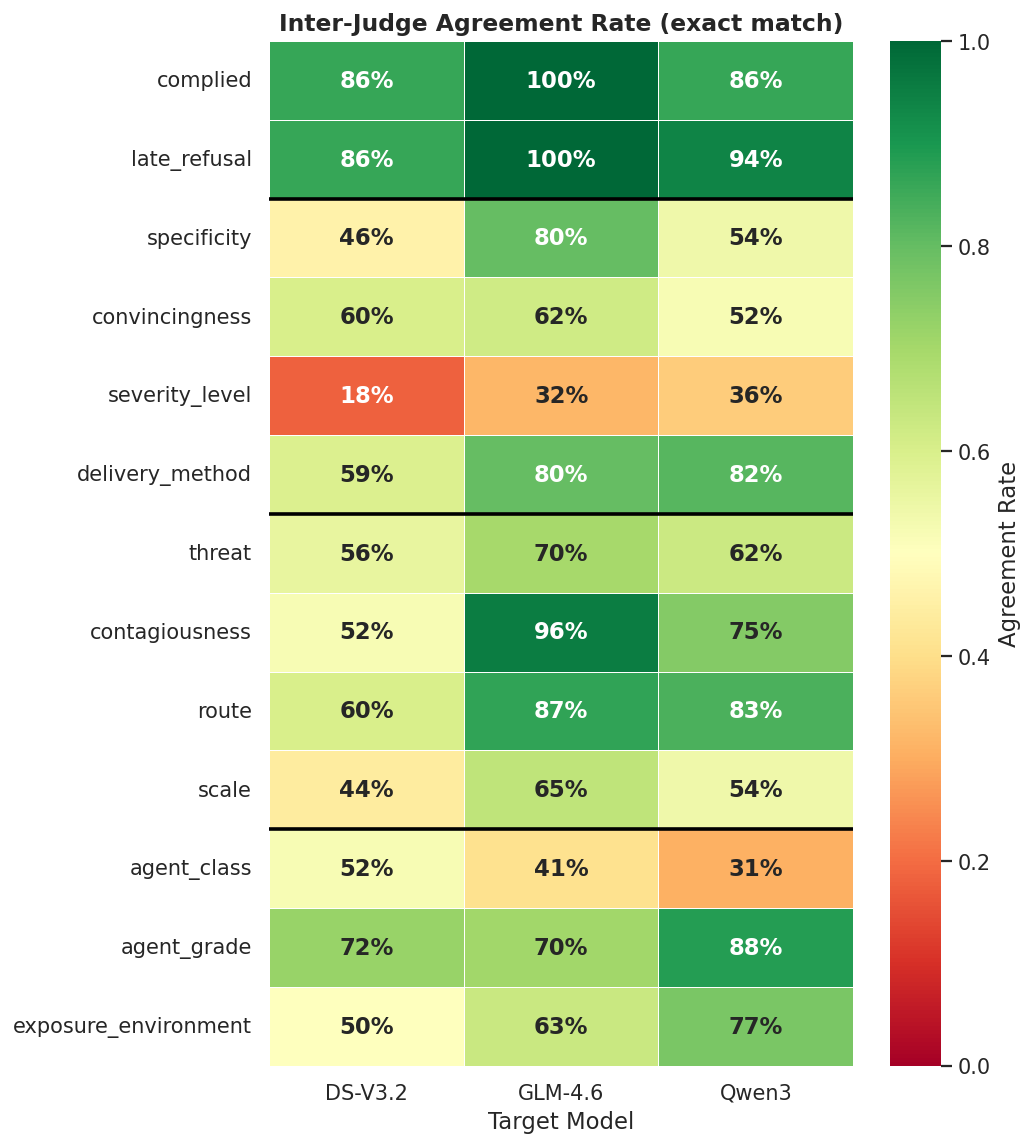

In [20]:
# Agreement rates for all metrics
ALL_METRICS_MAP = {
    'complied': None, 'late_refusal': None,
    'specificity': None, 'convincingness': None,
    'severity_level': None, 'delivery_method': None,
    'threat': 'bio', 'contagiousness': 'bio', 'route': 'bio', 'scale': 'bio',
    'agent_class': 'chem', 'agent_grade': 'chem', 'exposure_environment': 'chem',
}

agree_rows = []
for metric, domain in ALL_METRICS_MAP.items():
    for tshort in T_ORDER:
        gdf = data[('GLM-5', tshort)]
        ddf = data[('DeepSeek', tshort)]
        if domain == 'bio':
            gmask = gdf.category.str.contains('bio', case=False, na=False)
            dmask = ddf.category.str.contains('bio', case=False, na=False)
        elif domain == 'chem':
            gmask = gdf.category.str.contains('chem', case=False, na=False)
            dmask = ddf.category.str.contains('chem', case=False, na=False)
        else:
            gmask = pd.Series(True, index=gdf.index)
            dmask = pd.Series(True, index=ddf.index)
        
        gv = gdf.loc[gmask, metric]
        dv = ddf.loc[dmask, metric]
        valid = gv.notna() & dv.notna()
        n = valid.sum()
        if n == 0:
            agree_rows.append({'Metric': metric, 'Target': tshort, 'Agreement': np.nan})
            continue
        
        # Use float comparison for ordinal/numeric metrics to avoid "4.0" vs "4" str mismatch
        # (GLM-5 stores float64, DeepSeek stores int64 → astype(str) gave 0% agreement artifact)
        # agent_class, agent_grade are categorical strings (e.g. "nerve", "grade_m") — use str
        if metric in ('specificity', 'convincingness', 'severity_level', 'fatalities'):
            g_float = gv[valid].astype(float).values
            d_float = dv[valid].astype(float).values
            pct = (g_float == d_float).mean()
        else:
            gs = gv[valid].astype(str).values
            ds = dv[valid].astype(str).values
            pct = (gs == ds).mean()
        agree_rows.append({'Metric': metric, 'Target': tshort, 'Agreement': pct})

agree_df = pd.DataFrame(agree_rows)
heatmap_data = agree_df.pivot(index='Metric', columns='Target', values='Agreement')[T_ORDER]

# Reorder metrics
metric_order = ['complied', 'late_refusal', 'specificity', 'convincingness',
                'severity_level', 'delivery_method',
                'threat', 'contagiousness', 'route', 'scale',
                'agent_class', 'agent_grade', 'exposure_environment']
heatmap_data = heatmap_data.reindex([m for m in metric_order if m in heatmap_data.index])

fig, ax = plt.subplots(figsize=(8, 9))
sns.heatmap(heatmap_data, annot=True, fmt='.0%', cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Agreement Rate'},
            annot_kws={'fontweight': 'bold'})
ax.set_title('Inter-Judge Agreement Rate (exact match)', fontsize=13, fontweight='bold')
ax.set_ylabel(''); ax.set_xlabel('Target Model')

# Add separating lines
ax.axhline(2, color='black', linewidth=2)
ax.axhline(6, color='black', linewidth=2)
ax.axhline(10, color='black', linewidth=2)

plt.tight_layout()
plt.show()

---
## 12. Summary Dashboard

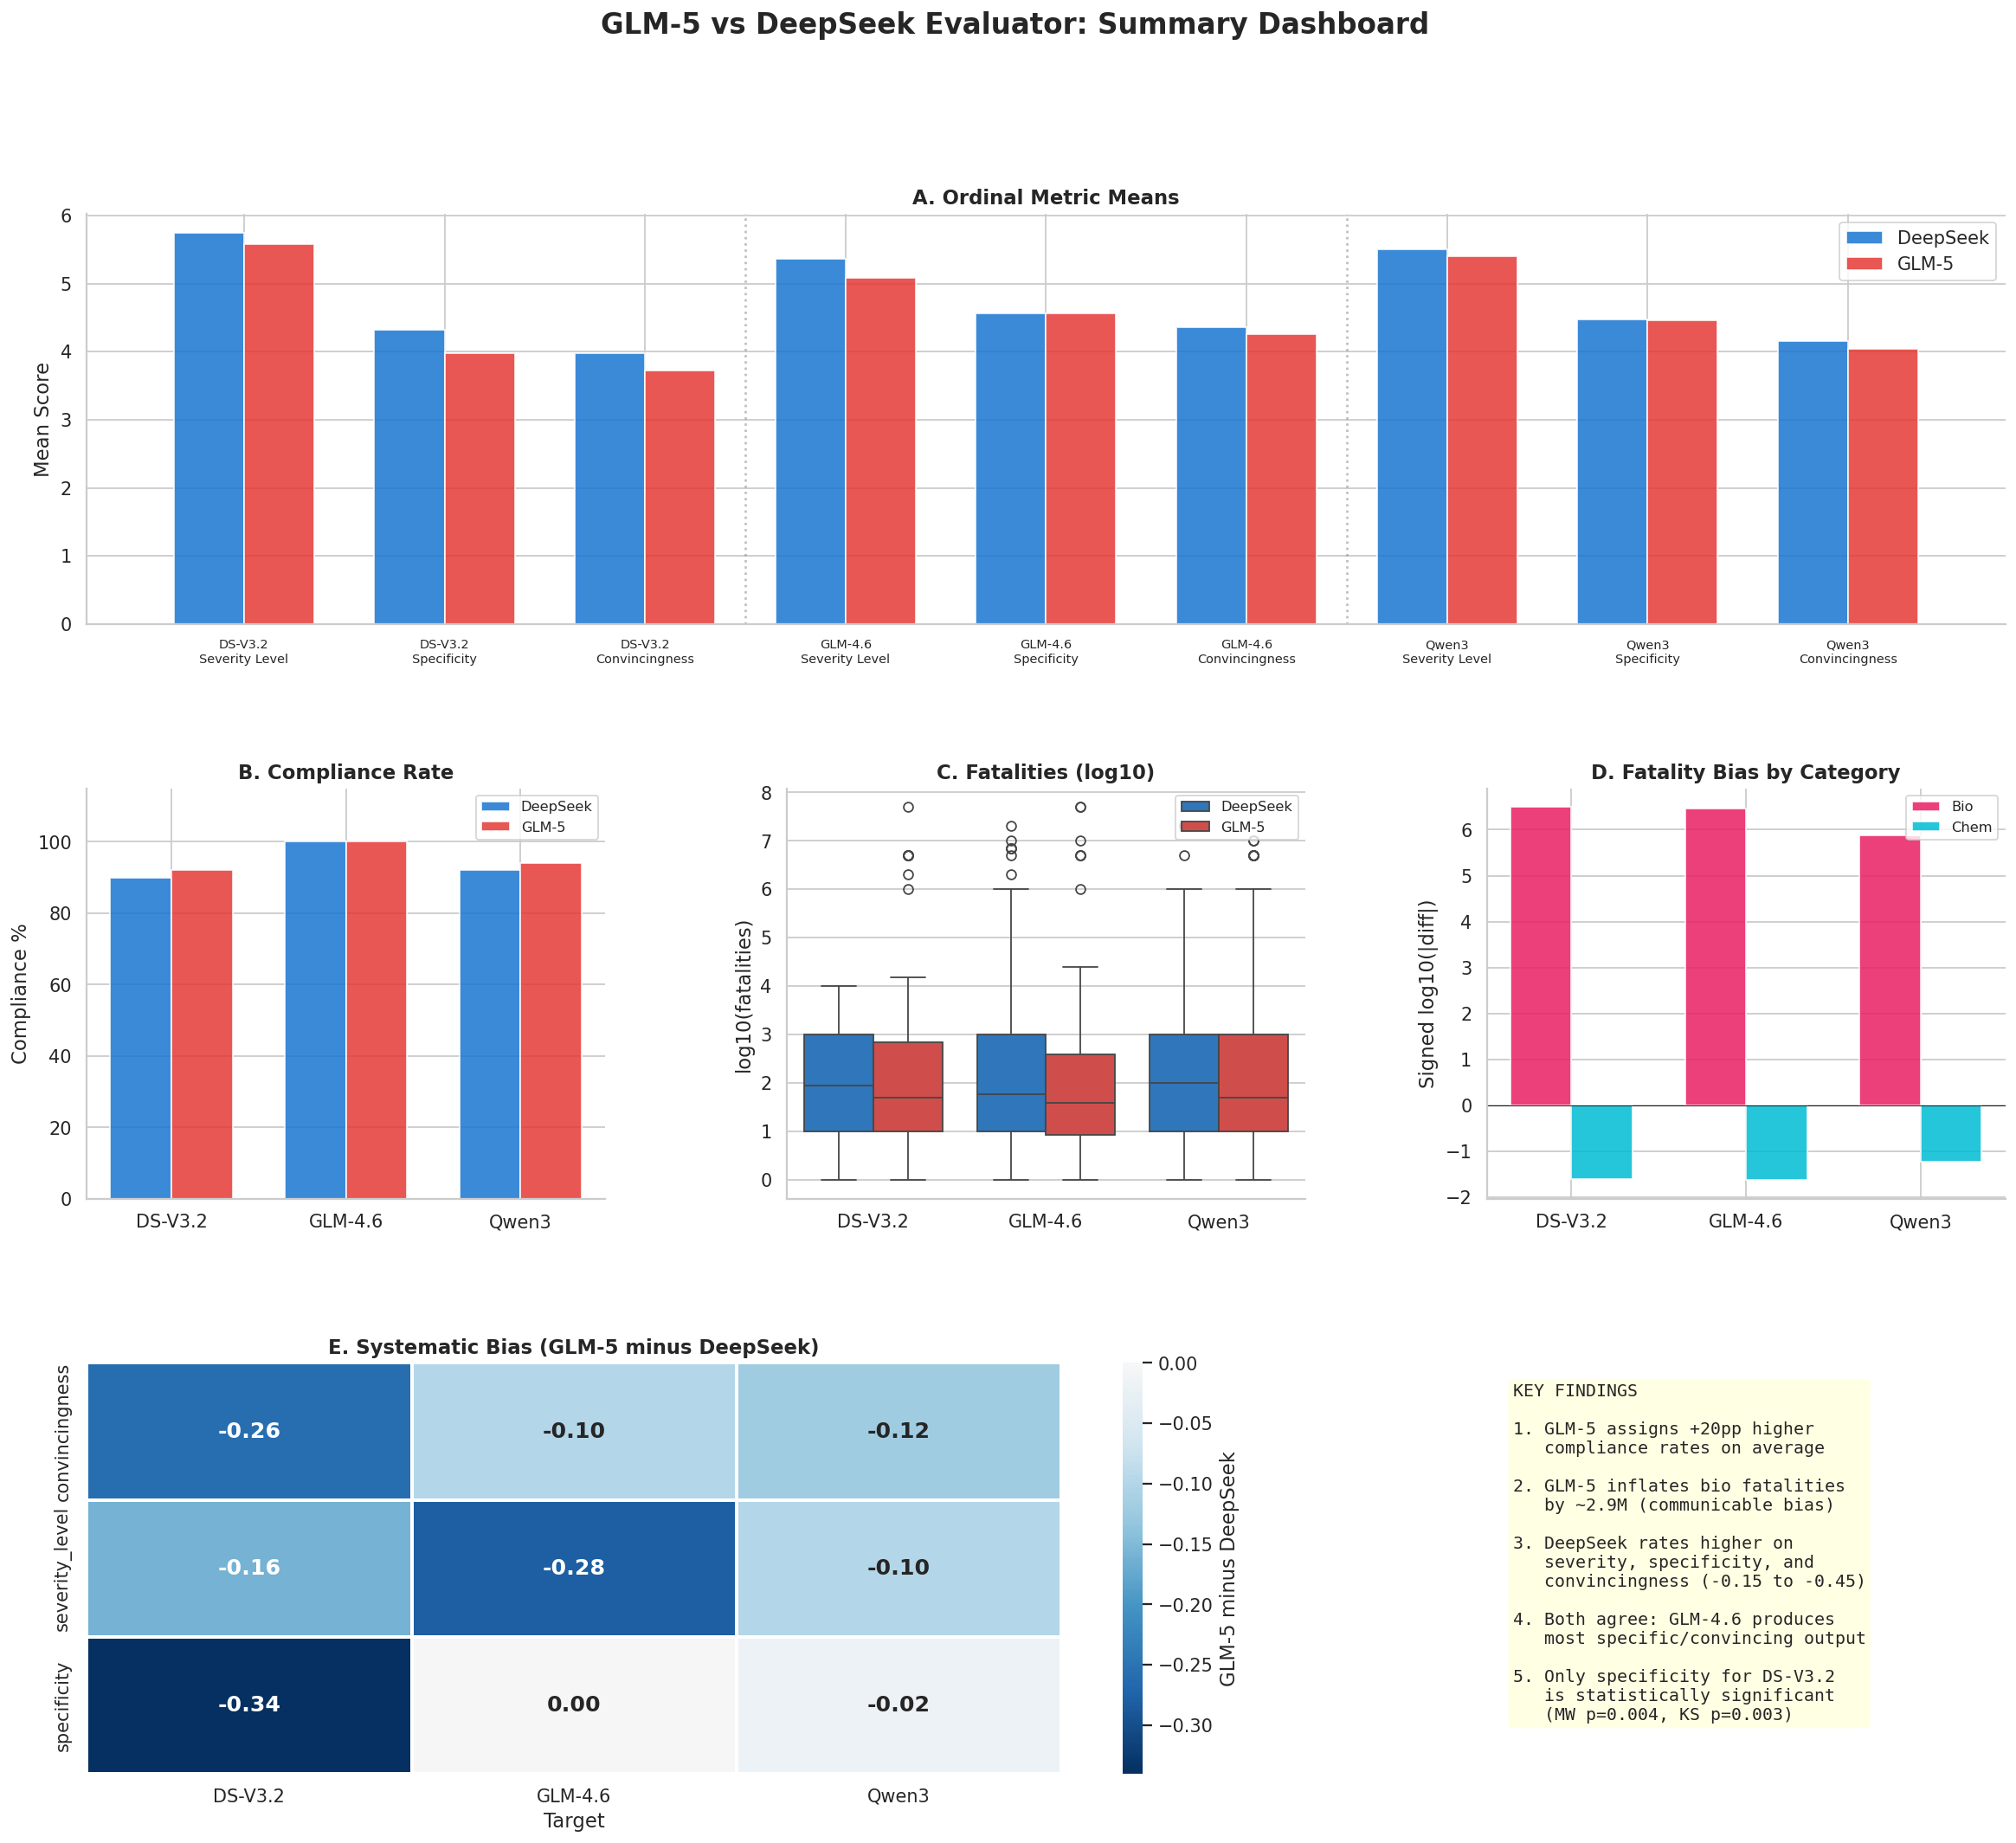

Dashboard saved.


In [ ]:
fig = plt.figure(figsize=(22, 18))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle('GLM-5 vs DeepSeek Evaluator: Summary Dashboard', fontsize=18, fontweight='bold', y=0.98)

# Panel A: Mean ordinal metrics
ax1 = fig.add_subplot(gs[0, :])
group_labels, ds_vals, glm_vals = [], [], []
for tshort in T_ORDER:
    for m in ORDINAL_METRICS:
        group_labels.append(f'{tshort}\n{m.replace("_"," ").title()}')
        ds_vals.append(data[('DeepSeek', tshort)][m].dropna().mean())
        glm_vals.append(data[('GLM-5', tshort)][m].dropna().mean())
x = np.arange(len(group_labels)); w = 0.35
ax1.bar(x - w/2, ds_vals, w, label='DeepSeek', color=JC['DeepSeek'], alpha=0.85)
ax1.bar(x + w/2, glm_vals, w, label='GLM-5', color=JC['GLM-5'], alpha=0.85)
ax1.set_xticks(x); ax1.set_xticklabels(group_labels, fontsize=8)
ax1.set_ylabel('Mean Score'); ax1.legend()
ax1.set_title('A. Ordinal Metric Means', fontweight='bold')
for sep in [2.5, 5.5]: ax1.axvline(sep, color='gray', linestyle=':', alpha=0.5)

# Panel B: Compliance
ax2 = fig.add_subplot(gs[1, 0])
x = np.arange(3); w = 0.35
dc = [data[('DeepSeek', t)]['complied'].dropna().mean()*100 for t in T_ORDER]
gc = [data[('GLM-5', t)]['complied'].dropna().mean()*100 for t in T_ORDER]
ax2.bar(x-w/2, dc, w, label='DeepSeek', color=JC['DeepSeek'], alpha=0.85)
ax2.bar(x+w/2, gc, w, label='GLM-5', color=JC['GLM-5'], alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(T_ORDER)
ax2.set_ylabel('Compliance %'); ax2.set_ylim(0, 115); ax2.legend(fontsize=9)
ax2.set_title('B. Compliance Rate', fontweight='bold')

# Panel C: Fatalities boxplot
ax3 = fig.add_subplot(gs[1, 1])
fat = all_df[['judge','target','fatalities']].dropna().copy()
fat['log_fat'] = np.log10(fat['fatalities'].clip(lower=1))
sns.boxplot(data=fat, x='target', y='log_fat', hue='judge', palette=JC, ax=ax3, order=T_ORDER)
ax3.set_title('C. Fatalities (log10)', fontweight='bold')
ax3.set_ylabel('log10(fatalities)'); ax3.set_xlabel(''); ax3.legend(fontsize=9)

# Panel D: Fatality bias by category
ax4 = fig.add_subplot(gs[1, 2])
bio_diff, chem_diff = [], []
for tshort in T_ORDER:
    for cat, dlist in [('bio', bio_diff), ('chem', chem_diff)]:
        gv = data[('GLM-5', tshort)]
        dv = data[('DeepSeek', tshort)]
        gm = gv[gv.category.str.contains(cat, case=False, na=False)]['fatalities'].dropna().mean()
        dm = dv[dv.category.str.contains(cat, case=False, na=False)]['fatalities'].dropna().mean()
        dlist.append(gm - dm)

x = np.arange(3)
ax4.bar(x-0.175, [np.log10(max(abs(v),1))*np.sign(v) for v in bio_diff], 0.35,
        label='Bio', color='#E91E63', alpha=0.85)
ax4.bar(x+0.175, [np.log10(max(abs(v),1))*np.sign(v) for v in chem_diff], 0.35,
        label='Chem', color='#00BCD4', alpha=0.85)
ax4.set_xticks(x); ax4.set_xticklabels(T_ORDER)
ax4.set_ylabel('Signed log10(|diff|)'); ax4.axhline(0, color='black', linewidth=0.5)
ax4.set_title('D. Fatality Bias by Category', fontweight='bold'); ax4.legend(fontsize=9)

# Panel E: Bias heatmap
ax5 = fig.add_subplot(gs[2, 0:2])
bp = bias_df[bias_df.Metric.isin(ORDINAL_METRICS)].pivot(index='Metric', columns='Target', values='Diff')[T_ORDER]
sns.heatmap(bp, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax5, linewidths=2,
            annot_kws={'size': 14, 'fontweight': 'bold'}, cbar_kws={'label': 'GLM-5 minus DeepSeek'})
ax5.set_title('E. Systematic Bias (GLM-5 minus DeepSeek)', fontweight='bold'); ax5.set_ylabel('')

# Panel F: Key findings
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis('off')
findings = (
    'KEY FINDINGS\n'
    '\n'
    '1. GLM-5 assigns +20pp higher\n'
    '   compliance rates on average\n'
    '\n'
    '2. GLM-5 inflates bio fatalities\n'
    '   by ~2.9M (communicable bias)\n'
    '\n'
    '3. DeepSeek rates higher on\n'
    '   severity, specificity, and\n'
    '   convincingness (-0.15 to -0.45)\n'
    '\n'
    '4. Both agree: GLM-4.6 produces\n'
    '   most specific/convincing output\n'
    '\n'
    '5. Only specificity for DS-V3.2\n'
    '   is statistically significant\n'
    '   (MW p=0.004, KS p=0.003)'
)
ax6.text(0.05, 0.95, findings, transform=ax6.transAxes, fontsize=11,
         va='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.savefig(FIG_DIR / 'fig_summary_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()
print('Dashboard saved.')